In [289]:
import numpy as np
import pandas as pd
import matplotlib
import sklearn
import matplotlib.pyplot as plt
import statsmodels
import seaborn as sns
from tqdm import tqdm
import re
import pickle
import scipy
import os
import scipy.stats as stats
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import KFold, train_test_split, GridSearchCV
from copy import deepcopy
from sklearn.utils import shuffle
from IPython.display import display, HTML
from sklearn.metrics import mean_squared_error, make_scorer, r2_score
from warnings import simplefilter
import warnings
# ignore all future warnings
from sklearn.exceptions import DataConversionWarning, FitFailedWarning
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore", category=DataConversionWarning)
warnings.filterwarnings("ignore", category=FitFailedWarning)
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import AnovaRM
from statsmodels.regression.mixed_linear_model import MixedLM
from statsmodels.formula.api import ols
display(HTML("<style>.container { width:85% !important; }</style>"))
sns.set_context(rc={'lines.linewidth': 2.5,
					'axes.labelsize': 25,
					'axes.titlesize': 19.200000000000003,
					'font.size': 25,
					'xtick.major.width': 8,
					'ytick.major.width': 8,
					'xtick.major.size':6,
					'ytick.major.size':6,
					'axes.linewidth':4})
def get_sig(p):
    if np.isnan(p):
        return ''
    elif p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

Inits

In [2]:
full_data = pd.read_pickle('multifiber.pickle')
# region and indexing-related variables / functions
region_ids = ['PrL (E)', 'PrL (I)', 'vLS (E)', 'vLS (I)', 'POA (E)', 'POA (I)',
	'BNST (E)', 'BNST (I)', 'AH (E)', 'AH (I)', 'MeA (E)', 'MeA (I)',
	'VMH (E)', 'VMH (I)', 'PAG (E)', 'PAG (I)', 'PMv (E)', 'PMv (I)', 'LHb (E)', 'LHb (I)',
	'PA (E)', 'PA (I)', 'NAc (DA)'] # populations
indices = {val: idx for idx, val in enumerate(region_ids)} # dictionary with IDs for remapping
agg_animals = ['3095', '3096', '3097', '4013', '4014', '4015', '4016', '91R2', '30L', '30B', '31R2', '29L2']
obs_animals = ['30R2', '29L', '86L', '87L2', '927R', '927L', '933R', '1162B', '1185']
non_animals = ['87R2', '87L', '87B', '86L2', '583L2', '583B', '1162L2', '1162R']
animals = np.concatenate([agg_animals, obs_animals, non_animals])

In [3]:
def format4analysis(full_data, animal_ID, binary_labels='attack labels', exp='aggression'):

	sessions = list(full_data.keys())
	region_index, region_id = pd.factorize(region_ids)
	epochs = [[0, 3], [3, 6], [6, 9], [9, 12], [12, 15], [15, 18], [18, 21], [21,24], [24, 28]]
	f = np.max([full_data[session].shape[0] for session in sessions])

	traces_lib = np.empty((f, len(region_index), 27))
	traces_lib[:] = np.nan
	
	# Initialize not_na_cols to handle case where no sessions are found
	not_na_cols = []

	# package recordings into traces_lib array

	if exp == 'aggression':
		sessions = [x for x in sessions if '_balbc_' in x or '_mCD1_' in x]
	elif exp == 'observation':
		sessions = [x for x in sessions if '_obs_' in x or '_OBSmCD1_' in x]
	elif exp == 'nonsocial':
		sessions = [x for x in sessions if '_toy_' in x or '_toyCD1_' in x]
	else:
		raise Exception("Please specify experience type as 'aggression' or 'observation'.")

	# Get matching sessions for this animal
	matching_sessions = [x for x in sessions if animal_ID in x]
	
	if not matching_sessions:
		print(f"Warning: No sessions found for animal {animal_ID}")
	
	for i, sesh in enumerate(matching_sessions):

		# format traces from each session to fit the big nan array above
		s = full_data[sesh]
		not_na_cols = s.columns[s.notna().all()].tolist()
		if s.shape[0] < f:
			nan_pad = np.zeros((f-s.shape[0], s.shape[1]))
			nan_pad[:] = np.nan
			nan_pad = pd.DataFrame(nan_pad, columns=s.columns)
			s = pd.concat([s, nan_pad], axis=0)

		# copy columns at specific locations
		for idx, roi in zip(region_index, region_id):
			try: 
				traces_lib[:, idx, i] = s[roi]
			except KeyError:
				traces_lib[:, idx, i] = np.nan

	# separate into epochs

	d1 = traces_lib[:, :, epochs[0][0]:epochs[0][1]]
	d2 = traces_lib[:, :, epochs[1][0]:epochs[1][1]]
	d3 = traces_lib[:, :, epochs[2][0]:epochs[2][1]]
	d4 = traces_lib[:, :, epochs[3][0]:epochs[3][1]]
	d5 = traces_lib[:, :, epochs[4][0]:epochs[4][1]]
	d6 = traces_lib[: ,:, epochs[5][0]:epochs[5][1]]
	d7 = traces_lib[: ,:, epochs[6][0]:epochs[6][1]]
	d8 = traces_lib[: ,:, epochs[7][0]:epochs[7][1]]
	d9 = traces_lib[: ,:, epochs[8][0]:epochs[8][1]]
	trial_comps = [d1, d2, d3, d4, d5, d6, d7, d8, d9] 

	return trial_comps, not_na_cols

def produce_XY(epoch, orig_idx):
	
	filtered_sessions = epoch[~np.isnan(epoch).all(axis=1)]
	
	X_idxs = [x for x in np.arange(filtered_sessions.shape[1]) if orig_idx != x]
	X = filtered_sessions[:, X_idxs]
	orig_X = X.copy()
	if np.isnan(X).any(axis=0).any(): # remove columns with nan
		has_nan = np.isnan(X).any(axis=0)
		X = X[:, ~has_nan]
	y_init = filtered_sessions[:, orig_idx]
	y = y_init.reshape(-1,1)

	return X, y

def fit_ridge(X, y, verbose=0):

	# Split dataset
	X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, shuffle=False)

	# Define the hyperparameters to search over
	param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

	# Define ridge regression model
	model = Ridge(fit_intercept=True, normalize=True)

	# Use GridSearchCV to perform a grid search with cross-validation
	# grid_search = GridSearchCV(model, param_grid, cv=3, scoring=make_scorer(r2_score))
	grid_search = GridSearchCV(model, param_grid, cv=None, scoring=make_scorer(r2_score))

	# Fit the grid search to the training data
	grid_search.fit(X, y)

	# Get the best hyperparameters found by the grid search
	best_params = grid_search.best_params_
	if verbose == 1:
		print('Best hyperparameters:', grid_search.best_params_)
		print('Best score:', grid_search.best_score_)

	# Train a new SVM classifier using the best hyperparameters
	best_model = Ridge(**best_params, fit_intercept=True, normalize=True) # rbf
	
	return X_train, X_test, y_train, y_test, best_model, grid_search.best_score_

def string_mapper(string_list, index):
	"""
	Maps a list of strings to indices in ascending order, and returns a function to retrieve the string for a given index.
	"""
	index_map = {i: string_list[i] for i in range(len(string_list))}
	
	def get_string(index):
		"""
		Returns the string corresponding to the given index in the mapping.
		"""
		return index_map[index]
	
	return get_string(index)

def format_weights(fold_weights, global_weights, rois):
	
	if fold_weights.shape[0] < global_weights.shape[0]:
		truncated_weights = np.zeros((global_weights.shape[0]))
		pres_idxs, miss_idxs = get_indices(rois)
		truncated_weights[pres_idxs] = np.array(np.mean(fold_weights, axis=1))
		truncated_weights[miss_idxs] = np.nan
		return truncated_weights
	else:
		return np.mean(fold_weights, axis=1)
	
def get_indices(partial_list):
	present_indices = [indices[val] for val in partial_list if val in indices]
	not_present = [val for val in np.arange(len(region_ids)) if val not in present_indices]
	return present_indices, not_present
	
def add_nan_values(matrix, rois, n_features=22):
	
	if len(rois) < n_features: 
		
		# Get roi indices
		pres_idxs, miss_idxs = get_indices(rois)
		# Create a copy of the original matrix to avoid modifying it
		matrix_copy = matrix.copy()
		# Create a 1D boolean mask that indicates where to add NaN values
		nan_mask = np.zeros(matrix_copy.shape[2], dtype=bool)
		print(miss_idxs)
		nan_mask[miss_idxs] = True
		# Add NaN values to the matrix
		matrix_copy = np.insert(matrix_copy, miss_idxs, np.nan, axis=2)
				
		return matrix_copy
	
	else:
		
		return matrix
	
def permutation_test(model, X_train, y_train, X_test, y_test, coefficients, rois, region_idx, n_permutations=100):
	
	shuf_model = deepcopy(model)
	max_coefs = np.zeros((n_permutations, 22))
	shuf_kos = np.zeros((n_permutations, 22))
	
	# Perform the permutations
	for i in range(n_permutations):
		
		# Shuffle the target variable (y)
		y_shuffled = shuffle(y_train)

		# Fit the model to the shuffled data
		shuf_model.fit(X_train, y_shuffled)
		shuf_best_score = r2_score(y_test, shuf_model.predict(X_test))

		# Store the maximum coefficient from the shuffled data
		max_coefs[i, :] = format_shuffled_weights(shuf_model.coef_, max_coefs, rois, region_idx)
		
		# Do knockout on shuffled model
		shuf_knockouts = np.zeros((shuf_model.coef_.shape[1]))
		for shuf_idx in np.arange(X_train.shape[1]):
			shuf_ko_model = deepcopy(shuf_model)
			new_shuf_coef=shuf_ko_model.coef_.copy()
			new_shuf_coef[:, shuf_idx] = 0.
			shuf_ko_model.coef_ = new_shuf_coef
			shuf_y_pred = shuf_ko_model.predict(X_test)
			shuf_ko_score = r2_score(y_test, shuf_y_pred)
			if shuf_ko_score < 0:
				shuf_ko_score = 0
			shuf_knockout_score_difference = shuf_best_score - shuf_ko_score
			if shuf_knockout_score_difference < 0:
				shuf_knockout_score_difference = 0
			shuf_knockouts[shuf_idx] = shuf_knockout_score_difference
		shuf_knockouts = shuf_knockouts.reshape((1, shuf_model.coef_.shape[1]))
			
		shuf_kos[i, :] = format_shuffled_weights(shuf_knockouts, shuf_kos, rois, region_idx)
		
	return max_coefs, shuf_kos

## Multi-area model

In [4]:
def grab_cluster_idxs(full_data, animal_ID, exp='aggression'):

	sessions = list(full_data.keys())

	if exp == 'aggression':
		sessions = [x for x in sessions if '_balbc_' in x or '_mCD1_' in x if animal_ID in x]
	elif exp == 'observation':
		sessions = [x for x in sessions if '_obs_' in x or '_OBSmCD1_' in x if animal_ID in x]
	elif exp == 'nonsocial':
		sessions = [x for x in sessions if '_toy_' in x or '_toyCD1_' in x if animal_ID in x]
	else:
		raise Exception("Please specify experience type as 'aggression' or 'observation'.")

	unsupervised_labels_4_all = []
	for session in sessions:
		d_labels = full_data[session]['unsupervised labels'].values
		placeholder = np.zeros((len(d_labels), 13))
		for i in np.arange(13):
			cluster_idx = np.where(d_labels==i+1)[0]
			placeholder[cluster_idx, i] = 1
		unsupervised_labels_4_all.append(placeholder)

	return unsupervised_labels_4_all

In [5]:
new_idx = np.array([12, 16, 8, 4, 10, 20, 6, 14, 2, 0, 18])
norm_idx = (new_idx/2).astype(int)
all_labels = [x.replace(' (E)', '').replace(' (I)', '').replace(' (DA)','') for x in np.array(region_ids)[new_idx]]

### ARD Regression (Figure 5)

Compute shared and unique variance:

In [6]:
from tqdm import tqdm
from sklearn.linear_model import ARDRegression, LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
import warnings

# Suppress warnings from ARD if it occasionally drops all features in a noisy fold
warnings.filterwarnings("ignore", category=UserWarning)

np.random.seed(42)
constrained_idxs = np.array([16, 8, 14, 13, 17, 3, 7, 9, 11]) # selected features
# Initialize global storage arrays
scores_const = np.zeros((27, 13, len(animals)))
weights_const = np.zeros((len(constrained_idxs), 27, 13, len(animals)))
knockouts_const = np.zeros((len(constrained_idxs), 27, 13, len(animals)))
shared_const = np.zeros((len(constrained_idxs), 27, 13, len(animals))) # NEW: Store shared variance

pbar = tqdm(enumerate(animals), total=len(animals)) 
nperms = 100

for a, animal in pbar:
	pbar.set_description('Processing animal %i' % a)
	
	# Load animal data
	if a <= 11:
		exp = 'aggression'
	elif a <= 20: 
		exp = 'observation'
	else:
		exp = 'nonsocial'

	trial_comps, rois = format4analysis(full_data, animal, exp=exp)
	rois = rois[:-2]
	norm_indices = [i for i, item in enumerate(region_ids) if item in set(rois)]
	trial_comps = np.concatenate(trial_comps, axis=2)
	cluster_comps = grab_cluster_idxs(full_data, animal, exp=exp)
	
	# Create arrays for storage of weights and % drop across epochs
	epoch_scores = np.zeros((trial_comps.shape[2], 13))
	epoch_scores[:] = np.nan
	epoch_weights = np.zeros((len(constrained_idxs), trial_comps.shape[2], 13))
	epoch_weights[:] = np.nan
	epoch_knockouts = epoch_weights.copy()
	epoch_shared = epoch_weights.copy() # NEW: Epoch-level shared container
	
	for e in np.arange(trial_comps.shape[-1]):
		epoch = trial_comps[:, :, e]
		for region_idx, orig_idx in enumerate(norm_indices):
			if orig_idx != 12: # only VMH
				continue
			
			# Format y
			y = epoch[:, region_idx]
			y = y[~np.isnan(y)].reshape(-1,1)
			if np.isnan(y).all():
				continue

			# Format X
			X = epoch[:, constrained_idxs]
			orig_X_shape = X.shape
			X = X[:, ~np.all(np.isnan(X), axis=0)]
			X = X[~np.any(np.isnan(X), axis=1)]
			new_X_shape = X.shape
			if new_X_shape[1] < len(constrained_idxs): # if a region is missing
				continue
			
			# Index into clusters
			for c in np.arange(cluster_comps[e].shape[1]):
				cluster_indices = np.where(cluster_comps[e][:, c]==1)[0]
				if len(cluster_indices) > 80:
					X_hat = X[cluster_indices, :]
					y_hat = y[cluster_indices, :].ravel() # Scikit-learn prefers 1D y
					
					try:
						# --- 1. K-Fold Cross Validation Setup ---
						kf = KFold(n_splits=3, shuffle=True, random_state=42)
						y_pred_full = np.zeros_like(y_hat)
						models = [] 
						
						# Train full ARD models across folds
						for train_idx, test_idx in kf.split(X_hat):
							model = ARDRegression()
							model.fit(X_hat[train_idx], y_hat[train_idx])
							y_pred_full[test_idx] = model.predict(X_hat[test_idx])
							models.append((model, train_idx, test_idx))
							
						# True Out-of-Sample Full R-squared
						best_score = max(r2_score(y_hat, y_pred_full), 0)
						epoch_scores[e, c] = best_score
						
						# Store average weights across the 5 folds
						avg_weights = np.mean([m[0].coef_ for m in models], axis=0)
						epoch_weights[:, e, c] = avg_weights
						
						# --- 2. Calculate Unique & Marginal Variance ---
						knockouts = np.zeros((X.shape[1]))
						shared_vars = np.zeros((X.shape[1]))
						
						for knockout_idx in np.arange(X.shape[1]):
							
							# A. Out-of-Sample Knockout (Unique Variance)
							avg_ko = []
							for n in np.arange(nperms):
								y_pred_ko = np.zeros_like(y_hat)
								for model, train_idx, test_idx in models:
									X_test_shuffled = X_hat[test_idx].copy()
									np.random.shuffle(X_test_shuffled[:, knockout_idx])
									y_pred_ko[test_idx] = model.predict(X_test_shuffled)
									
								ko_score = max(r2_score(y_hat, y_pred_ko), 0)
								avg_ko.append(ko_score)
								
							ko_score_mean = np.mean(avg_ko) 
							knockout_score_difference = max(best_score - ko_score_mean, 0)
							knockouts[knockout_idx] = knockout_score_difference
							
							# B. Marginal Model (Just this single region)
							y_pred_marg = np.zeros_like(y_hat)
							X_marg = X_hat[:, knockout_idx].reshape(-1, 1)
							
							for train_idx, test_idx in kf.split(X_marg):
								# OLS is perfectly fine for a single feature (no multicollinearity possible)
								marg_model = LinearRegression() 
								marg_model.fit(X_marg[train_idx], y_hat[train_idx])
								y_pred_marg[test_idx] = marg_model.predict(X_marg[test_idx])
								
							marginal_score = max(r2_score(y_hat, y_pred_marg), 0)
							
							# C. Shared Variance by Region
							shared_region = max(marginal_score - knockout_score_difference, 0)
							shared_vars[knockout_idx] = shared_region
							
						epoch_knockouts[:, e, c] = knockouts
						epoch_shared[:, e, c] = shared_vars
						
					except ValueError:
						continue

	# Store in global containers
	scores_const[:, :, a] = epoch_scores
	weights_const[:, :, :, a] = epoch_weights
	knockouts_const[:, :, :, a] = epoch_knockouts
	shared_const[:, :, :, a] = epoch_shared

Processing animal 0:   0%|          | 0/29 [00:00<?, ?it/s]

Processing animal 28: 100%|██████████| 29/29 [1:41:19<00:00, 209.64s/it]


Filtering OBS behavior with attention:

In [140]:
from tqdm import tqdm
from sklearn.linear_model import ARDRegression, LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
import warnings
import pickle

warnings.filterwarnings("ignore", category=UserWarning)

# ── Load attention labels ─────────────────────────────────────────────────────
with open('sniffing_labels_dict.pkl', 'rb') as file:
    sniffing_labels = pickle.load(file)

behavior_groups = {
    'Self-directed': [0, 3],
    'Idle': [5],
    'Exploratory': [1, 2, 6],
    'Sniffing': [4],
}
ATTENTION_LABELS = behavior_groups['Sniffing']

n_agg  = len(agg_animals)
n_obs  = len(obs_animals)
n_non  = len(non_animals)
OBS_START = n_agg
OBS_END   = n_agg + n_obs

TRAINING_EPOCHS = 24   # first 24 sessions/epochs; hard fight = last 3

def get_ordered_obs_sessions(animal, full_data):
    """
    Reconstructs the per-animal session list in the SAME order/filter used
    to build all_activity — this is the list we ASSUME format4analysis's
    trial_comps/cluster_comps epochs correspond to positionally. Must be
    verified against trial_comps.shape[-1] before trusting alignment.
    """
    return [x for x in list(full_data.keys()) if animal in x
            if '_obs_' in x or '_OBSmCD1_' in x]


np.random.seed(42)
constrained_idxs = np.array([16, 8, 14, 13, 17, 3, 7, 9, 11])

scores_const     = np.zeros((27, 13, len(animals)))
weights_const    = np.zeros((len(constrained_idxs), 27, 13, len(animals)))
knockouts_const  = np.zeros((len(constrained_idxs), 27, 13, len(animals)))
shared_const     = np.zeros((len(constrained_idxs), 27, 13, len(animals)))

# ── tracking for attention-filter fallback/diagnostics ────────────────────────
sessions_missing_labels    = []
sessions_length_mismatch   = []
alignment_warnings         = []

pbar = tqdm(enumerate(animals), total=len(animals))
nperms = 100

for a, animal in pbar:
    pbar.set_description('Processing animal %i' % a)

    if a <= 11:
        exp = 'aggression'
    elif a <= 20:
        exp = 'observation'
    else:
        exp = 'nonsocial'

    is_obs = OBS_START <= a < OBS_END

    trial_comps, rois = format4analysis(full_data, animal, exp=exp)
    rois = rois[:-2]
    norm_indices = [i for i, item in enumerate(region_ids) if item in set(rois)]
    trial_comps = np.concatenate(trial_comps, axis=2)
    cluster_comps = grab_cluster_idxs(full_data, animal, exp=exp)

    # ── build epoch -> attention mask lookup for this animal (OBS only) ──────
    epoch_attn_masks = {}   # e -> boolean array (n_frames,) or None (no filter)
    if is_obs:
        obs_sessions = get_ordered_obs_sessions(animal, full_data)

        n_epochs = trial_comps.shape[-1]
        if len(obs_sessions) != n_epochs:
            alignment_warnings.append(
                f'{animal}: len(obs_sessions)={len(obs_sessions)} != '
                f'trial_comps epochs={n_epochs} — epoch/session alignment UNVERIFIED')

        for e in range(min(len(obs_sessions), TRAINING_EPOCHS, n_epochs)):
            session = obs_sessions[e]
            is_obsmcd1 = 'CD1' in session

            if is_obsmcd1:
                alignment_warnings.append(
                    f'{animal}: epoch {e} (< {TRAINING_EPOCHS}) resolved to an '
                    f'OBSmCD1 session ({session}) — training/hard-fight split assumption may be wrong')
                epoch_attn_masks[e] = None
                continue

            # ── use the ACTUAL per-epoch frame count (matches cluster_comps[e],
            # which is what the mask is applied against later) — NOT
            # trial_comps.shape[0], which is a padded/fixed template length
            # shared across all 27 epochs and much larger than any individual
            # session's real duration. ─────────────────────────────────────
            n_frames_epoch = cluster_comps[e].shape[0]

            attn = sniffing_labels.get(session, None)

            if attn is None:
                sessions_missing_labels.append(session)
                epoch_attn_masks[e] = None
                continue

            attn = np.asarray(attn)

            if len(attn) >= n_frames_epoch:
                attn_trimmed = attn[-n_frames_epoch:]
            else:
                sessions_length_mismatch.append(session)
                epoch_attn_masks[e] = None
                continue

            epoch_attn_masks[e] = np.isin(attn_trimmed, ATTENTION_LABELS)

    # ── storage containers (unchanged) ────────────────────────────────────────
    epoch_scores = np.zeros((trial_comps.shape[2], 13))
    epoch_scores[:] = np.nan
    epoch_weights = np.zeros((len(constrained_idxs), trial_comps.shape[2], 13))
    epoch_weights[:] = np.nan
    epoch_knockouts = epoch_weights.copy()
    epoch_shared = epoch_weights.copy()

    for e in np.arange(trial_comps.shape[-1]):
        epoch = trial_comps[:, :, e]

        # ── attention mask for this epoch (OBS + training period only) ───────
        attn_mask_epoch = None
        if is_obs and e < TRAINING_EPOCHS:
            attn_mask_epoch = epoch_attn_masks.get(e, None)

        for region_idx, orig_idx in enumerate(norm_indices):
            if orig_idx != 12:
                continue

            y = epoch[:, region_idx]
            y = y[~np.isnan(y)].reshape(-1, 1)
            if np.isnan(y).all():
                continue

            X = epoch[:, constrained_idxs]
            orig_X_shape = X.shape
            X = X[:, ~np.all(np.isnan(X), axis=0)]
            X = X[~np.any(np.isnan(X), axis=1)]
            new_X_shape = X.shape
            if new_X_shape[1] < len(constrained_idxs):
                continue

            for c in np.arange(cluster_comps[e].shape[1]):
                cluster_mask = (cluster_comps[e][:, c] == 1)

                # ── apply attention filter, if active for this epoch ──────────
                if attn_mask_epoch is not None:
                    if len(attn_mask_epoch) != len(cluster_mask):
                        alignment_warnings.append(
                            f'{animal} epoch {e}: attn_mask len={len(attn_mask_epoch)} '
                            f'!= cluster_mask len={len(cluster_mask)} — skipping filter this epoch')
                    else:
                        cluster_mask = cluster_mask & attn_mask_epoch

                cluster_indices = np.where(cluster_mask)[0]

                if len(cluster_indices) > 80:
                    X_hat = X[cluster_indices, :]
                    y_hat = y[cluster_indices, :].ravel()

                    try:
                        kf = KFold(n_splits=3, shuffle=True, random_state=42)
                        y_pred_full = np.zeros_like(y_hat)
                        models = []

                        for train_idx, test_idx in kf.split(X_hat):
                            model = ARDRegression()
                            model.fit(X_hat[train_idx], y_hat[train_idx])
                            y_pred_full[test_idx] = model.predict(X_hat[test_idx])
                            models.append((model, train_idx, test_idx))

                        best_score = max(r2_score(y_hat, y_pred_full), 0)
                        epoch_scores[e, c] = best_score

                        avg_weights = np.mean([m[0].coef_ for m in models], axis=0)
                        epoch_weights[:, e, c] = avg_weights

                        knockouts = np.zeros((X.shape[1]))
                        shared_vars = np.zeros((X.shape[1]))

                        for knockout_idx in np.arange(X.shape[1]):
                            avg_ko = []
                            for n in np.arange(nperms):
                                y_pred_ko = np.zeros_like(y_hat)
                                for model, train_idx, test_idx in models:
                                    X_test_shuffled = X_hat[test_idx].copy()
                                    np.random.shuffle(X_test_shuffled[:, knockout_idx])
                                    y_pred_ko[test_idx] = model.predict(X_test_shuffled)

                                ko_score = max(r2_score(y_hat, y_pred_ko), 0)
                                avg_ko.append(ko_score)

                            ko_score_mean = np.mean(avg_ko)
                            knockout_score_difference = max(best_score - ko_score_mean, 0)
                            knockouts[knockout_idx] = knockout_score_difference

                            y_pred_marg = np.zeros_like(y_hat)
                            X_marg = X_hat[:, knockout_idx].reshape(-1, 1)

                            for train_idx, test_idx in kf.split(X_marg):
                                marg_model = LinearRegression()
                                marg_model.fit(X_marg[train_idx], y_hat[train_idx])
                                y_pred_marg[test_idx] = marg_model.predict(X_marg[test_idx])

                            marginal_score = max(r2_score(y_hat, y_pred_marg), 0)
                            shared_region = max(marginal_score - knockout_score_difference, 0)
                            shared_vars[knockout_idx] = shared_region

                        epoch_knockouts[:, e, c] = knockouts
                        epoch_shared[:, e, c] = shared_vars

                    except ValueError:
                        continue

    scores_const[:, :, a] = epoch_scores
    weights_const[:, :, :, a] = epoch_weights
    knockouts_const[:, :, :, a] = epoch_knockouts
    shared_const[:, :, :, a] = epoch_shared

Processing animal 28: 100%|██████████| 29/29 [1:38:15<00:00, 203.29s/it]


Wrangle data:

In [263]:
# Gather tables
all_tables = {}
animals2include = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28])
sessions2include = [0, 24]
behaviors = [0,1,2,3,4,6,7,8] 
# behaviors = np.arange(10, 13)
supercluster_kos = np.nanmean(knockouts_const[:, :, behaviors, :], axis=2)
weights2map = np.transpose(supercluster_kos, [1,0,2])
all_labels = ['PMv', 'AH', 'PAG', 'VMH', 'PMv', 'vLS', 'BNST', 'AH', 'MeA']


all_tables = []
for r, roi in enumerate(constrained_idxs):
	table = pd.DataFrame(columns=['cross_day', 'cross_session', 'within_day', 'subject', 'dependent_variable'])
	for animal in np.arange((len(np.concatenate([agg_animals, obs_animals, non_animals]))))[animals2include]:
		sample = weights2map[sessions2include[0]:sessions2include[1], r, animal]
		cross_day_info = np.repeat(np.arange(8), 3)[sessions2include[0]:sessions2include[1]].astype(float)
		within_day_info = np.tile(np.arange(3), 8)[sessions2include[0]:sessions2include[1]].astype(float)
		session_info = np.arange(24)[sessions2include[0]:sessions2include[1]].astype(float)
		subject_info = np.repeat(animal, 24)[sessions2include[0]:sessions2include[1]]
		if animal<=11:
			group_info = np.repeat(0, 24)[sessions2include[0]:sessions2include[1]]
		elif animal<=20:
			group_info = np.repeat(1, 24)[sessions2include[0]:sessions2include[1]]
		else:
			group_info = np.repeat(2, 24)[sessions2include[0]:sessions2include[1]]
		table = pd.concat([table, pd.DataFrame({'cross_day': cross_day_info, 'cross_session': session_info, 'within_day': within_day_info, 'subject': subject_info, 'exp_group': group_info, 'dependent_variable': sample})])
	all_tables.append(table)

C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_35132\466095786.py:7: RuntimeWarning: Mean of empty slice
  supercluster_kos = np.nanmean(knockouts_const[:, :, behaviors, :], axis=2)


Plotting and stats: training period

In [264]:
# Paired testing for interaction significance
# 1) Normality check (Shapiro-Wilk on the paired differences, early - late)
# 2) Variance check (Levene's test between early and late samples — reported
#    for diagnostic transparency; does not gate test choice, since paired
#    t-test validity depends on normality of differences, not equal variance
#    between the two related samples)
# 3) Paired t-test (if differences are normal) or Wilcoxon signed-rank test
#    (if not), preserving the a priori sidedness per region

def format_p(p):
    return f'{p:.3e}' if p < 1e-4 else f'{p:.4f}'

def get_alternative_for_region(region_label):
    """Inhibitory regions: a priori hypothesis of decrease (early > late) informed by reduced inhibitory tone → one-sided.
       Excitatory regions: no a priori hypothesis of increase → two-sided."""
    if '(I)' in region_label:
        return 'greater'   # testing early > late
    else:
        return 'two-sided'      # testing early < late

def test_paired_normality_and_compare(early_clean, late_clean, alternative='two-sided',
                                       alpha=0.05, verbose=False):
    """
    Returns dict: test used, statistic, df (t-test only), p_raw,
    normality_p (Shapiro on differences), levene_p (diagnostic only).
    """
    diffs = early_clean - late_clean
    n     = len(diffs)

    # ── 1. Normality of the paired differences ────────────────────────────────
    if n >= 3:
        _, p_norm = stats.shapiro(diffs)
    else:
        p_norm = np.nan
    normal_diffs = (not np.isnan(p_norm)) and (p_norm > alpha)

    # ── 2. Variance (diagnostic only — does not gate test choice) ─────────────
    if n >= 3:
        _, levene_p = stats.levene(early_clean, late_clean)
    else:
        levene_p = np.nan

    if verbose:
        print(f'  n={n}  Shapiro(diffs) p={format_p(p_norm) if not np.isnan(p_norm) else "n/a"}  '
              f'({"normal" if normal_diffs else "non-normal"})  '
              f'Levene p={format_p(levene_p) if not np.isnan(levene_p) else "n/a"} (diagnostic)')

    # ── 3. Test selection ──────────────────────────────────────────────────────
    if n < 3:
        return {'test': 'n/a', 'statistic': np.nan, 'df': np.nan,
                'p_raw': np.nan, 'normality_p': p_norm, 'levene_p': levene_p}

    if normal_diffs:
        stat, p = stats.ttest_rel(early_clean, late_clean, alternative=alternative)
        test_name = 'paired t-test'
        df = n - 1
    else:
        try:
            stat, p = stats.wilcoxon(early_clean, late_clean, alternative=alternative,
                                     zero_method='wilcox', mode='auto')
        except ValueError:
            stat, p = np.nan, np.nan
        test_name = 'Wilcoxon signed-rank'
        df = np.nan

    return {'test': test_name, 'statistic': stat, 'df': df, 'p_raw': p,
            'normality_p': p_norm, 'levene_p': levene_p}


region_labels_for_test = ['(E)' if r < 3 else '(I)' for r in range(len(all_labels))]
ard_predictors = ['PMv (E)', 'AH (E)', 'lPAG (E)',
                  'VMHvl (I)', 'PMv (I)', 'AH (I)', 'MeA (I)', 'vLS (I)', 'BNST (I)']
ard_idx = np.arange(9)
assert len(ard_idx) == 9, f"Expected 9 ARD predictors, found {len(ard_idx)}: " \
                          f"{[all_labels[i] for i in ard_idx]}"


# ── Run test and collect p-values for multiple comparisons ─────────────────────
nbehaviors = len(behaviors)
days = 3   # 1 day = 3 sessions; this collects differences between day 1 and day 8

agg_early = knockouts_const[:, 0:days, behaviors, 0:12].reshape(len(all_labels), days*nbehaviors, 12)
obs_early = knockouts_const[:, 0:days, behaviors, 12:21].reshape(len(all_labels), days*nbehaviors, 9)
non_early = knockouts_const[:, 0:days, behaviors, 21:].reshape(len(all_labels), days*nbehaviors, 8)
agg_late  = knockouts_const[:, -3-days:-3, behaviors, 0:12].reshape(len(all_labels), days*nbehaviors, 12)
obs_late  = knockouts_const[:, -3-days:-3, behaviors, 12:21].reshape(len(all_labels), days*nbehaviors, 9)
non_late  = knockouts_const[:, -3-days:-3, behaviors, 21:].reshape(len(all_labels), days*nbehaviors, 8)

all_agg_pvals = []
all_obs_pvals = []
all_non_pvals = []

stored_early_late = {}

comparison_groups = [
    (agg_early, agg_late, all_agg_pvals, "AGG"),
    (obs_early, obs_late, all_obs_pvals, "OBS"),
    (non_early, non_late, all_non_pvals, "NON")
]

for r, roi_name in enumerate(all_labels):
    stored_early_late[r] = {}
    alt = get_alternative_for_region(region_labels_for_test[r])

    for early_src, late_src, pval_list, label in comparison_groups:

        early_per_animal = np.nanmedian(early_src[r], axis=0)
        late_per_animal  = np.nanmedian(late_src[r],  axis=0)

        valid_mask  = ~np.isnan(early_per_animal) & ~np.isnan(late_per_animal)
        early_clean = early_per_animal[valid_mask]
        late_clean  = late_per_animal[valid_mask]

        test_result = test_paired_normality_and_compare(
            early_clean, late_clean, alternative=alt)

        stored_early_late[r][label] = {
            'early': early_clean, 'late': late_clean, 'n': len(early_clean),
            'alternative': alt,
            'test': test_result['test'],
            'statistic': test_result['statistic'],
            'df': test_result['df'],
            'normality_p': test_result['normality_p'],
            'levene_p': test_result['levene_p'],
        }

        if len(early_clean) > 2:
            pval_list.append(test_result['p_raw'])
        else:
            print(f"Warning: Insufficient paired animals for {roi_name} in {label} group "
                  f"(n={len(early_clean)}).")
            pval_list.append(np.nan)

    print(f'{roi_name:<10} alternative={alt}')

PMv        alternative=two-sided
AH         alternative=two-sided
PAG        alternative=two-sided
VMH        alternative=greater
PMv        alternative=greater
vLS        alternative=greater
BNST       alternative=greater
AH         alternative=greater
MeA        alternative=greater


c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a, func=_nanmedian, axis=axis, out=out,


In [265]:
from statsmodels.stats.multitest import multipletests

# ── split into E and I sub-families for FDR ────────────────────────────────────
e_idx = np.arange(3)
i_idx = np.arange(3, 9)

print(f'Excitatory family ({len(e_idx)}): {[all_labels[i] for i in e_idx]}')
print(f'Inhibitory family ({len(i_idx)}): {[all_labels[i] for i in i_idx]}')

def fdr_within_family(pvals_all, family_idx):
    """Apply FDR only within the given index subset; others stay NaN."""
    corrected = np.full(len(pvals_all), np.nan)
    family_p  = [pvals_all[i] for i in family_idx]
    valid     = [i for i, p in zip(family_idx, family_p) if not np.isnan(p)]
    if valid:
        _, corr, _, _ = multipletests(
            [pvals_all[i] for i in valid], method='fdr_tsbh')
        for rank, i in enumerate(valid):
            corrected[i] = corr[rank]
    return corrected

for group_label, pvals_raw in [('AGG', all_agg_pvals),
                                ('OBS', all_obs_pvals),
                                ('NON', all_non_pvals)]:
    pvals_full = np.full(len(all_labels), np.nan)
    for i in ard_idx:
        pvals_full[i] = pvals_raw[i]

    corr_e = fdr_within_family(pvals_full, e_idx)
    corr_i = fdr_within_family(pvals_full, i_idx)

    combined_corr = np.where(~np.isnan(corr_e), corr_e, corr_i)
    if group_label == 'AGG':
        p_agg_corrected = combined_corr
    elif group_label == 'OBS':
        p_obs_corrected = combined_corr
    else:
        p_non_corrected = combined_corr

print(f'\nFDR now applied within {len(e_idx)}-region E family and '
      f'{len(i_idx)}-region I family separately, restricted to the 9 ARD predictors.')

Excitatory family (3): ['PMv', 'AH', 'PAG']
Inhibitory family (6): ['VMH', 'PMv', 'vLS', 'BNST', 'AH', 'MeA']

FDR now applied within 3-region E family and 6-region I family separately, restricted to the 9 ARD predictors.


In [266]:
# ── Construct per-animal, per-day arrays for the full training period ────────
# (feeds into fit_lme_time_trend — replaces the early/late two-timepoint
# collapse with the full 8-day trajectory, one value per animal per day)

n_days       = 8
sess_per_day = 3
nbehaviors   = len(behaviors)

group_slices = {
    'AGG': slice(0, 12),
    'OBS': slice(12, 21),
    'NON': slice(21, None),   # matches non_early = knockouts_const[:, ..., 21:] convention
}

# animal name lists — reuse if already defined earlier in the session;
# otherwise fall back to positional indices
try:
    group_animal_names = {'AGG': agg_animals, 'OBS': obs_animals, 'NON': non_animals}
except NameError:
    group_animal_names = {
        'AGG': [f'AGG_{i}' for i in range(12)],
        'OBS': [f'OBS_{i}' for i in range(9)],
        'NON': [f'NON_{i}' for i in range(knockouts_const.shape[-1] - 21)],
    }

def build_animal_day_arrays(region_idx, group_label, n_days=n_days, sess_per_day=sess_per_day):
    """
    Collapses knockouts_const[region_idx] to one value per animal per day
    (nanmedian over behaviors and the sess_per_day sessions within each
    day — same collapse convention as the paired early/late code), then
    arranges into long-format arrays: value, animal_id, day_index.
    """
    group_slice   = group_slices[group_label]
    animal_names  = group_animal_names[group_label]
    n_animals     = len(animal_names)

    values_list, animal_list, day_list = [], [], []

    for day in range(n_days):
        start = day * sess_per_day
        end   = start + sess_per_day

        day_data = knockouts_const[region_idx, start:end, behaviors, group_slice]
        # shape: (sess_per_day, nbehaviors, n_animals) — collapse sessions+behaviors per animal
        per_animal_day = np.nanmean(day_data, axis=(0, 1))   # (n_animals,)

        for a_idx, val in enumerate(per_animal_day):
            values_list.append(val)
            animal_list.append(animal_names[a_idx] if a_idx < n_animals else f'unk_{a_idx}')
            day_list.append(day)

    values = np.array(values_list, dtype=float)
    animals = np.array(animal_list, dtype=object)
    days_arr = np.array(day_list, dtype=int)

    # ── filter out NaN values ─────────────────────────────────────────────────
    valid = ~np.isnan(values)
    return values[valid], animals[valid], days_arr[valid]


# ── Build for all 9 ARD-predictor regions, per group ──────────────────────────
region_labels_for_test = ['(E)' if r < 3 else '(I)' for r in range(len(all_labels))]
ard_predictors = ['PMv (E)', 'AH (E)', 'lPAG (E)',
                  'VMHvl (I)', 'PMv (I)', 'AH (I)', 'MeA (I)', 'vLS (I)', 'BNST (I)']
ard_idx = np.arange(9)
assert len(ard_idx) == 9, f"Expected 9 ARD predictors, found {len(ard_idx)}: " \
                          f"{[all_labels[i] for i in ard_idx]}"

agg_day_values, agg_animal_ids, agg_day_indices = {}, {}, {}
obs_day_values, obs_animal_ids, obs_day_indices = {}, {}, {}
non_day_values, non_animal_ids, non_day_indices = {}, {}, {}

for i in ard_idx:
    agg_day_values[i], agg_animal_ids[i], agg_day_indices[i] = build_animal_day_arrays(i, 'AGG')
    obs_day_values[i], obs_animal_ids[i], obs_day_indices[i] = build_animal_day_arrays(i, 'OBS')
    non_day_values[i], non_animal_ids[i], non_day_indices[i] = build_animal_day_arrays(i, 'NON')

# ── Sanity check ───────────────────────────────────────────────────────────────
print(f'{"="*90}')
print(f'Per-animal, per-day array construction — training period ({n_days} days, {sess_per_day} sessions/day)')
print(f'{"="*90}')
print(f'{"Region":<14} {"Group":<6} {"n_obs (long)":>13} {"n_animals":>10} {"n_days_present":>15}')
print(f'{"─"*90}')

for i in ard_idx:
    roi = all_labels[i]
    for group_label, vals, ids, days_arr in [
        ('AGG', agg_day_values[i], agg_animal_ids[i], agg_day_indices[i]),
        ('OBS', obs_day_values[i], obs_animal_ids[i], obs_day_indices[i]),
        ('NON', non_day_values[i], non_animal_ids[i], non_day_indices[i]),
    ]:
        valid = ~np.isnan(vals)
        n_valid       = valid.sum()
        n_animals_uniq = len(np.unique(ids[valid])) if n_valid > 0 else 0
        n_days_uniq    = len(np.unique(days_arr[valid])) if n_valid > 0 else 0
        print(f'{roi:<14} {group_label:<6} {n_valid:>13} {n_animals_uniq:>10} {n_days_uniq:>15}')

print(f'{"="*90}')

Per-animal, per-day array construction — training period (8 days, 3 sessions/day)
Region         Group   n_obs (long)  n_animals  n_days_present
──────────────────────────────────────────────────────────────────────────────────────────
PMv            AGG               56          7               8
PMv            OBS               72          9               8
PMv            NON               64          8               8
AH             AGG               56          7               8
AH             OBS               72          9               8
AH             NON               64          8               8
PAG            AGG               56          7               8
PAG            OBS               72          9               8
PAG            NON               64          8               8
VMH            AGG               56          7               8
VMH            OBS               72          9               8
VMH            NON               64          8               8
PMv     

C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_35132\3071868392.py:45: RuntimeWarning: Mean of empty slice
  per_animal_day = np.nanmean(day_data, axis=(0, 1))   # (n_animals,)


In [274]:
import statsmodels.formula.api as smf
import pandas as pd

def fit_lme_time_trend(day_values, animal_ids, day_indices, verbose=False):
    """
    day_values:   flat array of per-animal, per-day unique variance values
    animal_ids:   matching array of animal identifiers (same length)
    day_indices:  matching array of day indices (same length)
    Fits: value ~ day + (1 | animal)

    Tries multiple optimizer/method combinations before giving up, since
    convergence for small, unbalanced repeated-measures data can be
    sensitive to the fitting method (lbfgs is not always the most robust
    choice — powell/cg and ML vs REML can converge where lbfgs fails on
    the exact same data).

    Returns: slope, slope_se, p_value, converged (bool), method_used (str)
    """
    df = pd.DataFrame({
        'value':  day_values,
        'day':    day_indices,
        'animal': animal_ids,
    }).dropna()

    if df['animal'].nunique() < 3:
        return np.nan, np.nan, np.nan, False, 'n/a (too few animals)'

    model = smf.mixedlm('value ~ day', data=df, groups=df['animal'])

    attempts = [
        ('lbfgs',  True),
        ('powell', True),
        ('cg',     True),
        ('lbfgs',  False),
        ('powell', False),
        ('cg',     False),
    ]

    for method, reml in attempts:
        try:
            result = model.fit(reml=reml, method=method)
        except Exception:
            continue

        if result.converged:
            slope    = result.params.get('day', np.nan)
            slope_se = result.bse.get('day', np.nan)
            p_value  = result.pvalues.get('day', np.nan)
            method_label = f'{method}/{"REML" if reml else "ML"}'
            if verbose:
                print(f'    converged via {method_label}')
            return slope, slope_se, p_value, True, method_label

    return np.nan, np.nan, np.nan, False, 'none converged'


from statsmodels.stats.multitest import multipletests
e_idx = np.arange(3)
i_idx = np.arange(3, 9)

def fdr_within_family(pvals_all, family_idx):
    corrected = np.full(len(pvals_all), np.nan)
    family_p  = [pvals_all[i] for i in family_idx]
    valid     = [i for i, p in zip(family_idx, family_p) if not np.isnan(p)]
    if valid:
        _, corr, _, _ = multipletests(
            [pvals_all[i] for i in valid], method='fdr_bh')
        for rank, i in enumerate(valid):
            corrected[i] = corr[rank]
    return corrected

def get_alternative_for_region_lme(cell_type):
    if cell_type == 'inhibitory':
        return 'less'
    else:
        return 'two-sided'

# ── build LME p-values per group, per region ──────────────────────────────────
all_agg_pvals_lme = np.full(len(all_labels), np.nan)
all_obs_pvals_lme = np.full(len(all_labels), np.nan)
all_non_pvals_lme = np.full(len(all_labels), np.nan)

lme_fit_methods = {}   # track which method converged, per (region, group) — for reporting

for i in ard_idx:
    cell_type = 'inhibitory' if i in i_idx else 'excitatory'
    alt       = get_alternative_for_region_lme(cell_type)

    for group_label, pvals_arr, day_data, animal_data, day_idx_data in [
        ('AGG', all_agg_pvals_lme, agg_day_values[i], agg_animal_ids[i], agg_day_indices[i]),
        ('OBS', all_obs_pvals_lme, obs_day_values[i], obs_animal_ids[i], obs_day_indices[i]),
        ('NON', all_non_pvals_lme, non_day_values[i], non_animal_ids[i], non_day_indices[i]),
    ]:
        slope, se, p_two_sided, converged, method_used = fit_lme_time_trend(
            day_data, animal_data, day_idx_data)

        lme_fit_methods[(i, group_label)] = method_used

        if not converged or np.isnan(p_two_sided):
            pvals_arr[i] = np.nan
            continue

        if alt == 'two-sided':
            pvals_arr[i] = p_two_sided
        else:
            matches_direction = slope < 0
            pvals_arr[i] = p_two_sided / 2 if matches_direction else 1 - p_two_sided / 2

# ── same FDR correction as before, applied to the LME-derived p-values ───────
for group_label, pvals_full in [('AGG', all_agg_pvals_lme),
                                ('OBS', all_obs_pvals_lme),
                                ('NON', all_non_pvals_lme)]:
    corr_e = fdr_within_family(pvals_full, e_idx)
    corr_i = fdr_within_family(pvals_full, i_idx)
    combined_corr = np.where(~np.isnan(corr_e), corr_e, corr_i)
    if group_label == 'AGG':
        p_agg_corrected = combined_corr
    elif group_label == 'OBS':
        p_obs_corrected = combined_corr
    else:
        p_non_corrected = combined_corr

# ── convergence summary ────────────────────────────────────────────────────────
print(f'{"="*70}')
print(f'LME convergence summary')
print(f'{"="*70}')
print(f'{"Region":<14} {"Group":<6} {"Method used":<20}')
print(f'{"─"*70}')
for i in ard_idx:
    for group_label in ['AGG', 'OBS', 'NON']:
        print(f'{all_labels[i]:<14} {group_label:<6} {lme_fit_methods[(i, group_label)]:<20}')
n_failed = sum(1 for v in lme_fit_methods.values() if v == 'none converged')
print(f'{"─"*70}')
print(f'Failed to converge (any method): {n_failed} / {len(lme_fit_methods)}')
print(f'{"="*70}')

LME convergence summary
Region         Group  Method used         
──────────────────────────────────────────────────────────────────────
PMv            AGG    powell/REML         
PMv            OBS    lbfgs/REML          
PMv            NON    lbfgs/REML          
AH             AGG    lbfgs/REML          
AH             OBS    lbfgs/REML          
AH             NON    lbfgs/REML          
PAG            AGG    powell/REML         
PAG            OBS    lbfgs/REML          
PAG            NON    lbfgs/REML          
VMH            AGG    lbfgs/REML          
VMH            OBS    lbfgs/REML          
VMH            NON    lbfgs/REML          
PMv            AGG    lbfgs/REML          
PMv            OBS    lbfgs/REML          
PMv            NON    lbfgs/REML          
vLS            AGG    lbfgs/REML          
vLS            OBS    powell/REML         
vLS            NON    powell/REML         
BNST           AGG    lbfgs/REML          
BNST           OBS    powell/REML         
BN

C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_35132\3700077491.py:52: RuntimeWarning: Mean of empty slice
  animal_day_values = np.nanmean(day_data, axis=(0, 1))


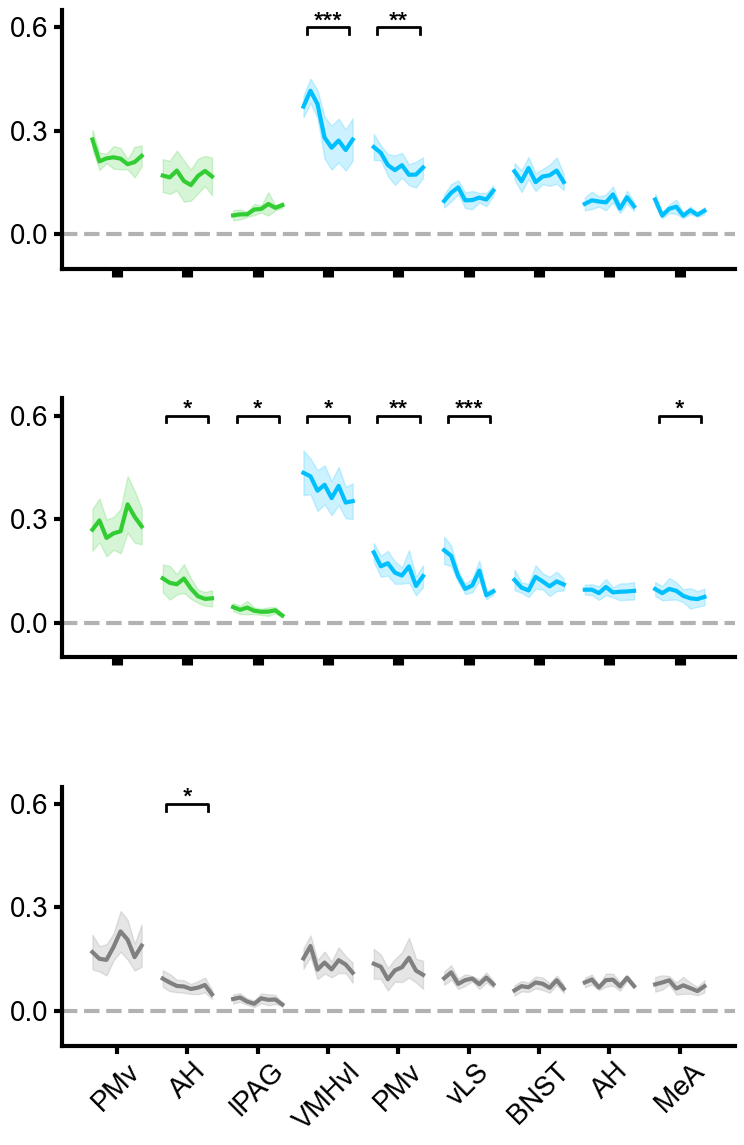


Unique variance over training — LME (value ~ day + (1|animal))
Inhibitory: one-sided (predicted decrease); Excitatory: two-sided
Correction: FDR-BH within E/I family, per group, restricted to the 9 ARD predictors
Group  Region     Alt        Converged       slope   slope_se        z     CI_lo     CI_hi     RE_var  Resid_var   n_obs  n_animals  n_days      p_raw      p_fdr   Sig
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
AGG    PMv        two-sided  True          -0.0047     0.0042   -1.136       n/a       n/a        n/a        n/a      56          7       8     0.2561     0.3841  n.s.
AGG    AH         two-sided  True           0.0002     0.0028    0.070       n/a       n/a        n/a        n/a      56          7       8     0.9441     0.9441  n.s.
AGG    PAG        two-sided  True           0.0047     0.0022    2.172       n/a      

In [276]:
from statsmodels.stats.multitest import multipletests

# ==========================================
# CENTRAL DESIGN CONTROL PANEL
# ==========================================
FS_TITLE   = 16
FS_LABEL_X = 20
FS_TICKS_X = 20
FS_TICKS_Y = 20
FS_STAR    = 18
LW_LINE    = 3
LW_BRACKET = 2
LW_AXIS    = 3
LW_H_LINE  = 3
BRACKET_Y  = 0.6
BRACKET_H  = 0.02
SPACING_H  = 0.5

# --- Parameters & Figure Setup ─────────────────────────────────────────────
n_days       = 8
sess_per_day = 3
factor       = 10
new_labels   = [x.replace('VMH', 'VMHvl').replace('PAG', 'lPAG') for x in all_labels]

fig, (ax_agg, ax_obs, ax_non) = plt.subplots(3, 1, figsize=(8, 12), sharex=True, sharey=True)
plt.rcParams['font.family'] = 'Arial'

def get_sig_marker(p):
    if p is None or np.isnan(p): return None
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return None

# ── use LME-derived FDR-corrected p-values instead of paired early/late ──────
group_configs = [
    (ax_agg, slice(0, 12),  'AGG', p_agg_corrected, False),
    (ax_obs, slice(12, 21), 'OBS', p_obs_corrected, False),
    (ax_non, slice(21, 29), 'NON', p_non_corrected, True)
]

for ax, group_slice, group_label, corrected_ps, is_non in group_configs:

    for r, roi_label in enumerate(all_labels):
        daily_medians = []
        daily_sems    = []

        for day in range(n_days):
            start = day * sess_per_day
            end   = start + sess_per_day
            day_data = knockouts_const[r, start:end, behaviors, group_slice]
            animal_day_values = np.nanmean(day_data, axis=(0, 1))
            daily_medians.append(np.nanmean(animal_day_values))
            daily_sems.append(stats.sem(animal_day_values, nan_policy='omit'))

        x_positions = np.arange(n_days) + (r * factor)
        medians     = np.array(daily_medians)
        errs        = np.array(daily_sems)

        color = 'grey' if is_non else ('limegreen' if r < 3 else 'deepskyblue')

        ax.plot(x_positions, medians, color=color, linewidth=LW_LINE)
        ax.fill_between(x_positions, medians - errs, medians + errs, alpha=0.2, color=color)

        # --- Significance Brackets — now reflect the LME time-trend p-value ──
        marker = get_sig_marker(corrected_ps[r])
        if marker:
            x_start = 0.5 + (r * factor)
            x_end   = 6.5 + (r * factor)
            ax.plot([x_start, x_start, x_end, x_end],
                    [BRACKET_Y - BRACKET_H, BRACKET_Y, BRACKET_Y, BRACKET_Y - BRACKET_H],
                    color='black', lw=LW_BRACKET)
            ax.text((x_start + x_end)/2, BRACKET_Y - 0.02, marker,
                    ha='center', va='bottom', fontsize=FS_STAR,
                    fontweight='bold', fontfamily='Arial')

    ax.set_ylim(-0.1, 0.65)
    ax.set_yticks([0, 0.3, 0.6])
    ax.tick_params(axis='y', which='both', left=True, labelleft=True, width=LW_AXIS)
    for label in ax.get_yticklabels():
        label.set_fontname('Arial')
        label.set_fontsize(FS_TICKS_Y)

    ax.axhline(0, color='black', linestyle='--', linewidth=LW_H_LINE, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(LW_AXIS)
    ax.spines['bottom'].set_linewidth(LW_AXIS)

tick_pos = np.arange(0, len(all_labels) * factor, factor) + 3.5
ax_non.set_xticks(tick_pos)
ax_non.set_xticklabels(new_labels, fontsize=FS_LABEL_X, rotation=45, fontfamily='Arial')
ax_non.tick_params(axis='x', which='both', bottom=True, labelbottom=True, width=LW_AXIS)

plt.tight_layout()
plt.subplots_adjust(hspace=SPACING_H)
plt.savefig('.\\figures\\fig5_VMH_variance_overtime_AGG_OBS_NON_comparison.svg', dpi=300, format='svg')
plt.show()

# ── Stats table — LME time-trend results, full statistics ────────────────────
print(f'\n{"="*195}')
print(f'Unique variance over training — LME (value ~ day + (1|animal))')
print(f'Inhibitory: one-sided (predicted decrease); Excitatory: two-sided')
print(f'Correction: FDR-BH within E/I family, per group, restricted to the 9 ARD predictors')
print(f'{"="*195}')
print(f'{"Group":<6} {"Region":<10} {"Alt":<10} {"Converged":<10} '
      f'{"slope":>10} {"slope_se":>10} {"z":>8} {"CI_lo":>9} {"CI_hi":>9} '
      f'{"RE_var":>10} {"Resid_var":>10} '
      f'{"n_obs":>7} {"n_animals":>10} {"n_days":>7} '
      f'{"p_raw":>10} {"p_fdr":>10} {"Sig":>5}')
print(f'{"─"*195}')

def _f(v, fmt='.4f'):
    return f'{v:{fmt}}' if not (v is None or (isinstance(v, float) and np.isnan(v))) else '     n/a'

for group_label, pvals_lme, pvals_corr, day_vals_dict, animal_ids_dict, day_idx_dict in [
    ('AGG', all_agg_pvals_lme, p_agg_corrected, agg_day_values, agg_animal_ids, agg_day_indices),
    ('OBS', all_obs_pvals_lme, p_obs_corrected, obs_day_values, obs_animal_ids, obs_day_indices),
    ('NON', all_non_pvals_lme, p_non_corrected, non_day_values, non_animal_ids, non_day_indices),
]:
    for i in ard_idx:
        roi        = all_labels[i]
        cell_type  = 'inhibitory' if i in i_idx else 'excitatory'
        alt        = get_alternative_for_region_lme(cell_type)

        vals, ids, days_arr = day_vals_dict[i], animal_ids_dict[i], day_idx_dict[i]
        slope, se, p_two_sided, converged, lme_result = fit_lme_time_trend(vals, ids, days_arr)

        # ── Pull remaining statistics from the fitted result object, if present ──
        z_stat, ci_lo, ci_hi, re_var, resid_var = np.nan, np.nan, np.nan, np.nan, np.nan
        if lme_result is not None:
            try:
                z_stat = slope / se if (se is not None and se not in (0, np.nan)) else np.nan
            except (TypeError, ZeroDivisionError):
                z_stat = np.nan
            try:
                ci = lme_result.conf_int()
                ci_lo, ci_hi = ci.loc['day', 0], ci.loc['day', 1]
            except (AttributeError, KeyError):
                pass
            try:
                re_var = float(lme_result.cov_re.values[0][0])
            except (AttributeError, IndexError):
                pass
            try:
                resid_var = lme_result.scale
            except AttributeError:
                pass

        p_raw = pvals_lme[i]
        p_fdr = pvals_corr[i]
        sig   = get_sig_marker(p_fdr) or 'n.s.'

        n_obs_pts      = len(vals)
        n_animals_uniq = len(np.unique(ids)) if n_obs_pts > 0 else 0
        n_days_uniq    = len(np.unique(days_arr)) if n_obs_pts > 0 else 0

        print(f'{group_label:<6} {roi:<10} {alt:<10} {str(converged):<10} '
              f'{_f(slope):>10} {_f(se):>10} {_f(z_stat, ".3f"):>8} '
              f'{_f(ci_lo):>9} {_f(ci_hi):>9} '
              f'{_f(re_var, ".6f"):>10} {_f(resid_var, ".6f"):>10} '
              f'{n_obs_pts:>7} {n_animals_uniq:>10} {n_days_uniq:>7} '
              f'{_f(p_raw):>10} {_f(p_fdr):>10} {sig:>5}')

    print(f'{"─"*195}')

print(f'{"="*195}')

In [278]:
# ── Source data export: 5i ────────────────────────────────────────────────────
os.makedirs('./sourceData', exist_ok=True)

# ── Rebuild LME stats lookup, keyed by region index (only ard_idx regions
# have real LME output — anon_agg_pvals_lme etc. are indexed by ALL region
# positions but non-ARD entries are never populated by the stats loop) ───────
lme_stats_lookup = {}  # (group_label, region_idx) -> dict of stats

for group_label, pvals_lme, pvals_corr, day_vals_dict, animal_ids_dict, day_idx_dict in [
    ('AGG', all_agg_pvals_lme, p_agg_corrected, agg_day_values, agg_animal_ids, agg_day_indices),
    ('OBS', all_obs_pvals_lme, p_obs_corrected, obs_day_values, obs_animal_ids, obs_day_indices),
    ('NON', all_non_pvals_lme, p_non_corrected, non_day_values, non_animal_ids, non_day_indices),
]:
    for i in ard_idx:
        cell_type = 'inhibitory' if i in i_idx else 'excitatory'
        alt       = get_alternative_for_region_lme(cell_type)

        vals, ids, days_arr = day_vals_dict[i], animal_ids_dict[i], day_idx_dict[i]
        slope, se, p_two_sided, converged, lme_result = fit_lme_time_trend(vals, ids, days_arr)

        z_stat, ci_lo, ci_hi, re_var, resid_var = np.nan, np.nan, np.nan, np.nan, np.nan
        if lme_result is not None:
            try:
                z_stat = slope / se if (se is not None and se not in (0, np.nan)) else np.nan
            except (TypeError, ZeroDivisionError):
                z_stat = np.nan
            try:
                ci = lme_result.conf_int()
                ci_lo, ci_hi = ci.loc['day', 0], ci.loc['day', 1]
            except (AttributeError, KeyError):
                pass
            try:
                re_var = float(lme_result.cov_re.values[0][0])
            except (AttributeError, IndexError):
                pass
            try:
                resid_var = lme_result.scale
            except AttributeError:
                pass

        lme_stats_lookup[(group_label, i)] = {
            'alternative': alt,
            'converged': converged,
            'slope': slope,
            'slope_se': se,
            'z': z_stat,
            'ci_lo': ci_lo,
            'ci_hi': ci_hi,
            're_var': re_var,
            'resid_var': resid_var,
            'p_raw': pvals_lme[i],
            'p_fdr': pvals_corr[i],
        }

# ── Individual per-animal, per-day values (matches the plotted trace + shading) ──
group_configs_export = [
    (slice(0, 12),  'AGG'),
    (slice(12, 21), 'OBS'),
    (slice(21, 29), 'NON'),
]

rows = []
for group_slice, group_label in group_configs_export:
    for r, roi_label in enumerate(all_labels):
        region_name = roi_label.replace('VMH', 'VMHvl').replace('PAG', 'lPAG')
        stats_here = lme_stats_lookup.get((group_label, r))  # None if r not in ard_idx

        for day in range(n_days):
            start = day * sess_per_day
            end   = start + sess_per_day
            day_data = knockouts_const[r, start:end, behaviors, group_slice]
            animal_day_values = np.nanmean(day_data, axis=(0, 1))

            row_base = {
                'region': region_name,
                'group': group_label,
                'day': day + 1,
                'daily_mean': np.nanmean(animal_day_values),
                'daily_sem': stats.sem(animal_day_values, nan_policy='omit'),
            }
            if stats_here is not None:
                row_base.update({f'lme_{k}': v for k, v in stats_here.items()})
            else:
                row_base.update({f'lme_{k}': np.nan for k in
                                 ['alternative', 'converged', 'slope', 'slope_se', 'z',
                                  'ci_lo', 'ci_hi', 're_var', 'resid_var', 'p_raw', 'p_fdr']})

            for a, val in enumerate(animal_day_values):
                row_base[f'animal_{a}'] = val
            rows.append(row_base)

sourceData_5i = pd.DataFrame(rows)
sourceData_5i.to_csv('./sourceData/5i.csv', index=False)

C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_35132\1046994758.py:72: RuntimeWarning: Mean of empty slice
  animal_day_values = np.nanmean(day_data, axis=(0, 1))


Plot - hard fight:

c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a, func=_nanmedian, axis=axis, out=out,


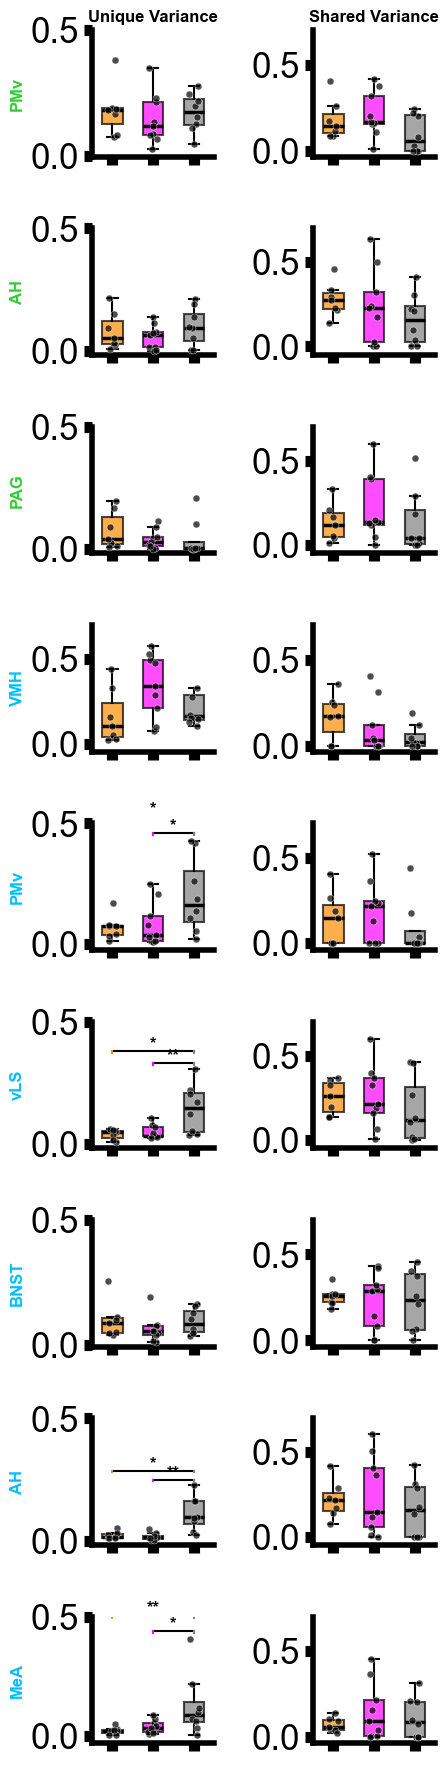


Unique Variance — one-sided pairwise tests vs NON (normality → variance → t-test/Welch t-test/Brunner-Munzel, no omnibus)
  a priori hypothesis: excitatory agnostic (alt=two-sided), inhibitory decrease (alt=less)
  FDR within E/I family, per group (AGG, OBS)
Shared Variance — two-sided pairwise tests vs NON (same test-selection logic)
  FDR within region, across the 2 comparisons (AGG vs NON, OBS vs NON)
Region         Var      Comparison   Alt        Test                   stat      df   norm_pA   norm_pB  levene_p      p_raw      p_fdr   Sig
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
PMv            Unique   AGG vs NON   two-sided  t-test               0.1916    13.0    0.0896    0.9678    0.9810     0.8510     0.8510      
PMv            Unique   OBS vs NON   two-sided  t-test              -0.5865    15.0    0.3237    0.9678    0.7045     0.5662     0.5662      
PMv 

In [272]:
from statsmodels.stats.multitest import multipletests
from scipy.stats import shapiro, brunnermunzel
import matplotlib.gridspec as gridspec

groups_bar   = ['AGG', 'OBS', 'NON']
group_colors = ['darkorange', 'magenta', 'gray']

def format_p(p):
    if p is None or np.isnan(p): return 'n/a'
    return f'{p:.3e}' if p < 1e-4 else f'{p:.4f}'

def get_sig(p):
    if p is None or np.isnan(p): return ''
    elif p < 0.001: return '***'
    elif p < 0.01:  return '**'
    elif p < 0.05:  return '*'
    else:           return ''

def add_comparison_bracket(ax, x1, x2, y, p_val, colors):
    if p_val is None or np.isnan(p_val): return
    if p_val < 0.001:   sig = '***'
    elif p_val < 0.01:  sig = '**'
    elif p_val < 0.05:  sig = '*'
    else:               return
    h = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.02
    ax.plot([x1, x2], [y, y], color='black', linewidth=1.5)
    ax.plot([x1, x1], [y - h, y], color=colors[0], linewidth=1.5)
    ax.plot([x2, x2], [y - h, y], color=colors[1], linewidth=1.5)
    ax.text((x1 + x2) / 2, y, sig, ha='center', va='bottom',
            fontsize=12, fontweight='bold', fontfamily='Arial')

def compute_df_for_test(test_name, a, b):
    if test_name == 't-test':
        return len(a) + len(b) - 2
    elif test_name == 'Welch t-test':
        v1, v2 = np.var(a, ddof=1), np.var(b, ddof=1)
        n1, n2 = len(a), len(b)
        return (v1/n1 + v2/n2)**2 / ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))
    else:
        return np.nan

def get_alternative_for_unique(cell_type):
    """
    A priori hypothesis: EXP/OBS decrease unique variance in inhibitory
    populations and increase it in excitatory populations, relative to NON.
    """
    if cell_type == 'inhibitory':
        return 'less'      # AGG < NON, OBS < NON
    else:
        return 'two-sided'   # AGG > NON, OBS > NON

def run_pairwise_stats(a, b, alternative='two-sided', alpha=0.05, variance_alpha=0.05):
    """
    Single pairwise comparison, no omnibus:
    1) Normality (Shapiro, both groups)
    2) Variance (Levene always; Bartlett too if both normal)
    3) Test selection: t-test (normal+equal var) / Welch t-test
       (normal+unequal var) / Brunner-Munzel (non-normal)
    Returns dict: test, statistic, df, p_raw, normality_ps, levene_p.
    """
    if len(a) < 3 or len(b) < 3:
        return {'test': 'n/a', 'statistic': np.nan, 'df': np.nan, 'p_raw': np.nan,
                'normality_ps': (np.nan, np.nan), 'levene_p': np.nan}

    _, p_norm_a = shapiro(a)
    _, p_norm_b = shapiro(b)
    normality_passed = (p_norm_a > alpha) and (p_norm_b > alpha)

    levene_stat, levene_p = stats.levene(a, b)
    equal_variances = levene_p > variance_alpha
    if normality_passed:
        _, bartlett_p = stats.bartlett(a, b)
        equal_variances = equal_variances and (bartlett_p > variance_alpha)

    if normality_passed and equal_variances:
        stat, p = stats.ttest_ind(a, b, equal_var=True, alternative=alternative)
        test_name = 't-test'
    elif normality_passed and not equal_variances:
        stat, p = stats.ttest_ind(a, b, equal_var=False, alternative=alternative)
        test_name = 'Welch t-test'
    else:
        stat, p = brunnermunzel(a, b, alternative=alternative)
        test_name = 'Brunner-Munzel'

    df_val = compute_df_for_test(test_name, a, b)

    return {'test': test_name, 'statistic': stat, 'df': df_val, 'p_raw': p,
            'normality_ps': (p_norm_a, p_norm_b), 'levene_p': levene_p}

def fdr_within_family(pvals_all, family_idx):
    """Apply FDR-BH only within the given index subset; others stay NaN."""
    corrected = np.full(len(pvals_all), np.nan)
    valid = [i for i in family_idx if not np.isnan(pvals_all[i])]
    if valid:
        _, corr, _, _ = multipletests([pvals_all[i] for i in valid], method='fdr_bh')
        for rank, i in enumerate(valid):
            corrected[i] = corr[rank]
    return corrected

# --- 1. Slicing the Data (unchanged) ─────────────────────────────────────────
behaviors = [0, 1, 2, 3, 4, 6, 7, 8]

agg_ko = knockouts_const[:, -3:, behaviors, 0:12].reshape(len(all_labels), len(behaviors)*3, 12)
obs_ko = knockouts_const[:, -3:, behaviors, 12:21].reshape(len(all_labels), len(behaviors)*3, 9)
non_ko = knockouts_const[:, -3:, behaviors, 21:].reshape(len(all_labels), len(behaviors)*3, 8)

agg_sh = shared_const[:, -3:, behaviors, 0:12].reshape(len(all_labels), len(behaviors)*3, 12)
obs_sh = shared_const[:, -3:, behaviors, 12:21].reshape(len(all_labels), len(behaviors)*3, 9)
non_sh = shared_const[:, -3:, behaviors, 21:].reshape(len(all_labels), len(behaviors)*3, 8)

agg_r2 = scores_const[-3:, behaviors, 0:12].reshape(len(behaviors)*3, 12)
obs_r2 = scores_const[-3:, behaviors, 12:21].reshape(len(behaviors)*3, 9)
non_r2 = scores_const[-3:, behaviors, 21:].reshape(len(behaviors)*3, 8)

agg_sum_unique = np.nansum(agg_ko, axis=0)
obs_sum_unique = np.nansum(obs_ko, axis=0)
non_sum_unique = np.nansum(non_ko, axis=0)

agg_shared = np.clip(agg_r2 - agg_sum_unique, a_min=0, a_max=None)
obs_shared = np.clip(obs_r2 - obs_sum_unique, a_min=0, a_max=None)
non_shared = np.clip(non_r2 - non_sum_unique, a_min=0, a_max=None)

# --- 2. First pass: raw pairwise p-values for all regions (Unique + Shared) ──
e_idx = [r for r in range(len(all_labels)) if r < 3]
i_idx = [r for r in range(len(all_labels)) if r >= 3]

raw_agg_non_u = np.full(len(all_labels), np.nan)
raw_obs_non_u = np.full(len(all_labels), np.nan)
raw_agg_non_s = np.full(len(all_labels), np.nan)
raw_obs_non_s = np.full(len(all_labels), np.nan)
unique_alt_by_region = {}

stored_ph = {}

for r, roi in enumerate(all_labels):
    try:
        agg_roi_activity = np.nanmedian(agg_ko[r], axis=0)
        obs_roi_activity = np.nanmedian(obs_ko[r], axis=0)
        non_roi_activity = np.nanmedian(non_ko[r], axis=0)
        agg_roi_shared = np.nanmedian(agg_sh[r], axis=0)
        obs_roi_shared = np.nanmedian(obs_sh[r], axis=0)
        non_roi_shared = np.nanmedian(non_sh[r], axis=0)

        agg_roi_activity = agg_roi_activity[~np.isnan(agg_roi_activity)]
        obs_roi_activity = obs_roi_activity[~np.isnan(obs_roi_activity)]
        non_roi_activity = non_roi_activity[~np.isnan(non_roi_activity)]
        agg_roi_shared = agg_roi_shared[~np.isnan(agg_roi_shared)]
        obs_roi_shared = obs_roi_shared[~np.isnan(obs_roi_shared)]
        non_roi_shared = non_roi_shared[~np.isnan(non_roi_shared)]

        cell_type = 'inhibitory' if r >= 3 else 'excitatory'
        alt_u     = get_alternative_for_unique(cell_type)

        # ── Unique: AGG vs NON, OBS vs NON — one-sided per cell type ────────────
        res_agg_non_u = run_pairwise_stats(agg_roi_activity, non_roi_activity, alternative=alt_u)
        res_obs_non_u = run_pairwise_stats(obs_roi_activity, non_roi_activity, alternative=alt_u)
        raw_agg_non_u[r] = res_agg_non_u['p_raw']
        raw_obs_non_u[r] = res_obs_non_u['p_raw']
        unique_alt_by_region[r] = alt_u

        # ── Shared: AGG vs NON, OBS vs NON — two-sided ───────────────────────────
        res_agg_non_s = run_pairwise_stats(agg_roi_shared, non_roi_shared, alternative='two-sided')
        res_obs_non_s = run_pairwise_stats(obs_roi_shared, non_roi_shared, alternative='two-sided')
        raw_agg_non_s[r] = res_agg_non_s['p_raw']
        raw_obs_non_s[r] = res_obs_non_s['p_raw']

        stored_ph[r] = {
            'label': roi, 'cell_type': cell_type,
            'detail_agg_non_u': res_agg_non_u, 'detail_obs_non_u': res_obs_non_u,
            'detail_agg_non_s': res_agg_non_s, 'detail_obs_non_s': res_obs_non_s,
            'agg_u': agg_roi_activity, 'obs_u': obs_roi_activity, 'non_u': non_roi_activity,
            'agg_s': agg_roi_shared, 'obs_s': obs_roi_shared, 'non_s': non_roi_shared,
        }
    except ValueError as e:
        print(f"Error processing {roi}: {e}")
        continue

# --- 3a. Family-wise FDR correction for Unique variance (E/I, per group) ────
corr_agg_non_u_e = fdr_within_family(raw_agg_non_u, e_idx)
corr_agg_non_u_i = fdr_within_family(raw_agg_non_u, i_idx)
p_agg_non_u = np.where(~np.isnan(corr_agg_non_u_e), corr_agg_non_u_e, corr_agg_non_u_i)

corr_obs_non_u_e = fdr_within_family(raw_obs_non_u, e_idx)
corr_obs_non_u_i = fdr_within_family(raw_obs_non_u, i_idx)
p_obs_non_u = np.where(~np.isnan(corr_obs_non_u_e), corr_obs_non_u_e, corr_obs_non_u_i)

# --- 3b. Region-wise FDR correction for Shared variance (AGG_NON + OBS_NON within region) ──
p_agg_non_s = np.full(len(all_labels), np.nan)
p_obs_non_s = np.full(len(all_labels), np.nan)
for r in range(len(all_labels)):
    pvals = [raw_agg_non_s[r], raw_obs_non_s[r]]
    valid = [i for i, p in enumerate(pvals) if not np.isnan(p)]
    if valid:
        _, corr, _, _ = multipletests([pvals[i] for i in valid], method='fdr_bh')
        for rank, i in enumerate(valid):
            if i == 0: p_agg_non_s[r] = corr[rank]
            if i == 1: p_obs_non_s[r] = corr[rank]

for r in stored_ph:
    stored_ph[r]['Unique'] = {
        'AGG_NON': p_agg_non_u[r], 'AGG_NON_raw': raw_agg_non_u[r],
        'OBS_NON': p_obs_non_u[r], 'OBS_NON_raw': raw_obs_non_u[r],
        'alternative': unique_alt_by_region[r],
    }
    stored_ph[r]['Shared'] = {
        'AGG_NON': p_agg_non_s[r], 'AGG_NON_raw': raw_agg_non_s[r],
        'OBS_NON': p_obs_non_s[r], 'OBS_NON_raw': raw_obs_non_s[r],
    }

# --- 4. Figure Setup (unchanged plotting logic) ──────────────────────────────
factor = 1.0
fig = plt.figure(figsize=(5, (len(all_labels) + 1) * 2 * factor))
gs  = gridspec.GridSpec(len(all_labels) + 1, 2, width_ratios=[1.0, 1.0], figure=fig)
plt.rcParams['font.family'] = 'Arial'

axes = []
for i in range(1, len(all_labels) + 1):
    axes.append([fig.add_subplot(gs[i, 0]), fig.add_subplot(gs[i, 1])])
axes = np.array(axes)

rng = np.random.default_rng(42)

for r, roi in enumerate(all_labels):
    if r not in stored_ph:
        continue
    store = stored_ph[r]
    agg_roi_activity, obs_roi_activity, non_roi_activity = store['agg_u'], store['obs_u'], store['non_u']
    agg_roi_shared, obs_roi_shared, non_roi_shared = store['agg_s'], store['obs_s'], store['non_s']

    # --- LEFT COLUMN: Unique Variance ────────────────────────────────────────
    ax_bar_u = axes[r, 0]
    data_u   = [agg_roi_activity, obs_roi_activity, non_roi_activity]

    bp = ax_bar_u.boxplot(data_u, positions=range(3), widths=0.5,
                          patch_artist=True, showfliers=False,
                          medianprops=dict(color='black', linewidth=2.5),
                          boxprops=dict(linewidth=1.5, edgecolor='black'),
                          whiskerprops=dict(linewidth=1.5, color='black'),
                          capprops=dict(linewidth=1.5, color='black'))
    for patch, c in zip(bp['boxes'], group_colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    for i, d in enumerate(data_u):
        jitter = rng.uniform(-0.12, 0.12, size=len(d))
        ax_bar_u.scatter(np.full(len(d), i) + jitter, d, color='black', s=25, alpha=0.7,
                         zorder=5, edgecolors='white', linewidths=0.4)

    ax_bar_u.set_xticks(range(3))
    ax_bar_u.set_xticklabels(groups_bar, fontfamily='Arial')
    ax_bar_u.tick_params(axis='both', which='both', labelbottom=True, labelleft=True, bottom=True, left=True)
    ax_bar_u.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1f}'))
    if r == 0:
        ax_bar_u.set_title("Unique Variance", fontfamily='Arial', fontsize=12, fontweight='bold')
    for label in ax_bar_u.get_yticklabels():
        label.set_fontfamily('Arial')

    # significance brackets — AGG vs NON (0,2) and OBS vs NON (1,2) only
    max_h_u = np.nanmax(np.concatenate(data_u))
    bh_u    = max_h_u * 0.08
    if get_sig(store['Unique']['OBS_NON']):
        y_pos = max_h_u + bh_u
        add_comparison_bracket(ax_bar_u, 1, 2, y_pos, store['Unique']['OBS_NON'], ['magenta', 'grey'])
        max_h_u = y_pos + bh_u
    if get_sig(store['Unique']['AGG_NON']):
        y_pos = max_h_u + bh_u
        add_comparison_bracket(ax_bar_u, 0, 2, y_pos, store['Unique']['AGG_NON'], ['darkorange', 'grey'])

    all_pts_u = np.concatenate(data_u)
    ylim_max = 0.7 if r == 3 else 0.5
    ax_bar_u.set_ylim(min(0, np.nanmin(all_pts_u) - bh_u), ylim_max)
    color = 'limegreen' if r < 3 else 'deepskyblue'
    ax_bar_u.set_ylabel(roi, color=color, fontfamily='Arial', fontweight='bold', fontsize=12)
    ax_bar_u.set_xticklabels([])

    # --- RIGHT COLUMN: Shared Variance ───────────────────────────────────────
    ax_bar_s = axes[r, 1]
    data_s   = [agg_roi_shared, obs_roi_shared, non_roi_shared]

    bp_s = ax_bar_s.boxplot(data_s, positions=range(3), widths=0.5,
                            patch_artist=True, showfliers=False,
                            medianprops=dict(color='black', linewidth=2.5),
                            boxprops=dict(linewidth=1.5, edgecolor='black'),
                            whiskerprops=dict(linewidth=1.5, color='black'),
                            capprops=dict(linewidth=1.5, color='black'))
    for patch, c in zip(bp_s['boxes'], group_colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    for i, d in enumerate(data_s):
        jitter = rng.uniform(-0.12, 0.12, size=len(d))
        ax_bar_s.scatter(np.full(len(d), i) + jitter, d, color='black', s=25, alpha=0.7,
                         zorder=5, edgecolors='white', linewidths=0.4)

    ax_bar_s.set_xticks(range(3))
    ax_bar_s.set_xticklabels(groups_bar, fontfamily='Arial')
    ax_bar_s.tick_params(axis='both', which='both', labelbottom=True, labelleft=True, bottom=True, left=True)
    ax_bar_s.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1f}'))
    if r == 0:
        ax_bar_s.set_title("Shared Variance", fontfamily='Arial', fontsize=12, fontweight='bold')
    for label in ax_bar_s.get_yticklabels():
        label.set_fontfamily('Arial')

    max_h_s = np.nanmax(np.concatenate(data_s))
    bh_s    = max_h_s * 0.08
    if get_sig(store['Shared']['OBS_NON']):
        y_pos = max_h_s + bh_s
        add_comparison_bracket(ax_bar_s, 1, 2, y_pos, store['Shared']['OBS_NON'], ['black', 'black'])
        max_h_s = y_pos + bh_s
    if get_sig(store['Shared']['AGG_NON']):
        y_pos = max_h_s + bh_s
        add_comparison_bracket(ax_bar_s, 0, 2, y_pos, store['Shared']['AGG_NON'], ['black', 'black'])

    all_pts_s = np.concatenate(data_s)
    ax_bar_s.set_ylim(min(0, np.nanmin(all_pts_s) - bh_s), 0.7)
    ax_bar_s.set_xticklabels([])

plt.tight_layout()
sns.despine()
plt.savefig('.\\figures\\fig5_VMH_variance_and_knockouts_by_animal.svg', dpi=300, format='svg')
plt.show()

# ── Stats table ────────────────────────────────────────────────────────────────
print(f'\n{"="*160}')
print(f'Unique Variance — one-sided pairwise tests vs NON (normality → variance → '
      f't-test/Welch t-test/Brunner-Munzel, no omnibus)')
print(f'  a priori hypothesis: excitatory agnostic (alt=two-sided), inhibitory decrease (alt=less)')
print(f'  FDR within E/I family, per group (AGG, OBS)')
print(f'Shared Variance — two-sided pairwise tests vs NON (same test-selection logic)')
print(f'  FDR within region, across the 2 comparisons (AGG vs NON, OBS vs NON)')
print(f'{"="*160}')
print(f'{"Region":<14} {"Var":<8} {"Comparison":<12} {"Alt":<10} {"Test":<16} '
      f'{"stat":>10} {"df":>7} {"norm_pA":>9} {"norm_pB":>9} {"levene_p":>9} '
      f'{"p_raw":>10} {"p_fdr":>10} {"Sig":>5}')
print(f'{"─"*160}')

for r in range(len(all_labels)):
    if r not in stored_ph:
        continue
    store = stored_ph[r]
    roi = store['label']

    for var_label, comp_label, key, detail_key in [
        ('Unique', 'AGG vs NON', 'AGG_NON', 'detail_agg_non_u'),
        ('Unique', 'OBS vs NON', 'OBS_NON', 'detail_obs_non_u'),
        ('Shared', 'AGG vs NON', 'AGG_NON', 'detail_agg_non_s'),
        ('Shared', 'OBS vs NON', 'OBS_NON', 'detail_obs_non_s'),
    ]:
        target = store['Unique'] if var_label == 'Unique' else store['Shared']
        p_fdr  = target[key]
        p_raw  = target[f'{key}_raw']
        alt    = target.get('alternative', 'two-sided')
        detail = store[detail_key]

        test_name = detail['test']
        stat_val  = detail['statistic']
        df_val    = detail['df']
        norm_a, norm_b = detail['normality_ps']
        levene_p  = detail['levene_p']

        stat_str = f'{stat_val:.4f}' if not np.isnan(stat_val) else 'n/a'
        df_str   = f'{df_val:.1f}'   if not np.isnan(df_val)   else 'n/a'

        print(f'{roi:<14} {var_label:<8} {comp_label:<12} {alt:<10} {test_name:<16} '
              f'{stat_str:>10} {df_str:>7} {format_p(norm_a):>9} {format_p(norm_b):>9} '
              f'{format_p(levene_p):>9} {format_p(p_raw):>10} {format_p(p_fdr):>10} {get_sig(p_fdr):>5}')

    print(f'{"─"*160}')

print(f'{"="*160}')

In [279]:
# ── Source data export: 5j ────────────────────────────────────────────────────
os.makedirs('./sourceData', exist_ok=True)

rows = []

for r in range(len(all_labels)):
    if r not in stored_ph:
        continue
    store = stored_ph[r]
    roi = store['label'].replace('VMH', 'VMHvl').replace('PAG', 'lPAG')
    cell_type = store['cell_type']

    # ── Unique variance ───────────────────────────────────────────────────────
    for group_label, vals in [('EXP', store['agg_u']), ('OBS', store['obs_u']), ('NON', store['non_u'])]:
        d_agg = store['detail_agg_non_u']
        d_obs = store['detail_obs_non_u']
        alt   = store['Unique']['alternative']

        for v in vals:
            rows.append({
                'region': roi, 'cell_type': cell_type, 'variance_type': 'Unique',
                'group': group_label, 'value': v,
                'alternative': alt,
                'agg_vs_non_test':   d_agg['test'],
                'agg_vs_non_stat':   d_agg['statistic'],
                'agg_vs_non_df':     d_agg['df'],
                'agg_vs_non_norm_pA': d_agg['normality_ps'][0],
                'agg_vs_non_norm_pB': d_agg['normality_ps'][1],
                'agg_vs_non_levene_p': d_agg['levene_p'],
                'agg_vs_non_p_raw':  store['Unique']['AGG_NON_raw'],
                'agg_vs_non_p_fdr':  store['Unique']['AGG_NON'],
                'obs_vs_non_test':   d_obs['test'],
                'obs_vs_non_stat':   d_obs['statistic'],
                'obs_vs_non_df':     d_obs['df'],
                'obs_vs_non_norm_pA': d_obs['normality_ps'][0],
                'obs_vs_non_norm_pB': d_obs['normality_ps'][1],
                'obs_vs_non_levene_p': d_obs['levene_p'],
                'obs_vs_non_p_raw':  store['Unique']['OBS_NON_raw'],
                'obs_vs_non_p_fdr':  store['Unique']['OBS_NON'],
                # unique variance has no agg_vs_obs comparison — no hypothesis, not tested
                'agg_vs_obs_test': np.nan, 'agg_vs_obs_stat': np.nan, 'agg_vs_obs_df': np.nan,
                'agg_vs_obs_p_raw': np.nan, 'agg_vs_obs_p_fdr': np.nan,
            })

    # ── Shared variance ───────────────────────────────────────────────────────
    for group_label, vals in [('EXP', store['agg_s']), ('OBS', store['obs_s']), ('NON', store['non_s'])]:
        d_agg = store['detail_agg_non_s']
        d_obs = store['detail_obs_non_s']

        for v in vals:
            rows.append({
                'region': roi, 'cell_type': cell_type, 'variance_type': 'Shared',
                'group': group_label, 'value': v,
                'alternative': 'two-sided',
                'agg_vs_non_test':   d_agg['test'],
                'agg_vs_non_stat':   d_agg['statistic'],
                'agg_vs_non_df':     d_agg['df'],
                'agg_vs_non_norm_pA': d_agg['normality_ps'][0],
                'agg_vs_non_norm_pB': d_agg['normality_ps'][1],
                'agg_vs_non_levene_p': d_agg['levene_p'],
                'agg_vs_non_p_raw':  store['Shared']['AGG_NON_raw'],
                'agg_vs_non_p_fdr':  store['Shared']['AGG_NON'],
                'obs_vs_non_test':   d_obs['test'],
                'obs_vs_non_stat':   d_obs['statistic'],
                'obs_vs_non_df':     d_obs['df'],
                'obs_vs_non_norm_pA': d_obs['normality_ps'][0],
                'obs_vs_non_norm_pB': d_obs['normality_ps'][1],
                'obs_vs_non_levene_p': d_obs['levene_p'],
                'obs_vs_non_p_raw':  store['Shared']['OBS_NON_raw'],
                'obs_vs_non_p_fdr':  store['Shared']['OBS_NON'],
                # shared variance also drops agg_vs_obs per this cell's design
                # (only AGG_NON/OBS_NON computed — no AGG_OBS comparison exists)
                'agg_vs_obs_test': np.nan, 'agg_vs_obs_stat': np.nan, 'agg_vs_obs_df': np.nan,
                'agg_vs_obs_p_raw': np.nan, 'agg_vs_obs_p_fdr': np.nan,
            })

sourceData_5j = pd.DataFrame(rows)
sourceData_5j.to_csv('./sourceData/5j.csv', index=False)

--- Final Day Total R-squared Stats (FDR Corrected) ---
AGG vs OBS: p = 0.5450 (n.s.)
AGG vs NON: p = 0.3427 (n.s.)
OBS vs NON: p = 0.5450 (n.s.)


C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_7980\3988190847.py:18: RuntimeWarning: Mean of empty slice
  r2_agg_final = np.nanmean(agg_r2, axis=0)


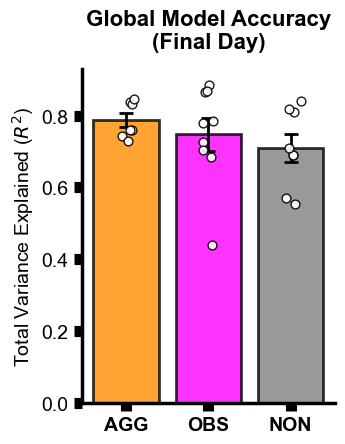

In [ ]:
# Model fits
plt.rcParams['font.family'] = 'Arial'
FS_TITLE = 16
FS_TICKS = 14
LW_AXIS = 2.5
colors = ['darkorange', 'magenta', 'grey']
groups = ['AGG', 'OBS', 'NON']

agg_r2 = scores_const[-3:, behaviors, 0:12].reshape(len(behaviors)*3, 12)
obs_r2 = scores_const[-3:, behaviors, 12:21].reshape(len(behaviors)*3, 9)
non_r2 = scores_const[-3:, behaviors, 21:].reshape(len(behaviors)*3, 8)

# --- 1. Extract and Collapse R-squared Data ---
# agg_r2 shape is (24, 12) -> (sessions*behaviors, animals)
# We average across the 24 behavioral/session slices to get 1 value per animal
r2_agg_final = np.nanmean(agg_r2, axis=0) 
r2_obs_final = np.nanmean(obs_r2, axis=0) 
r2_non_final = np.nanmean(non_r2, axis=0) 

# Clean out any potential NaNs for the stats
r2_agg_clean = r2_agg_final[~np.isnan(r2_agg_final)]
r2_obs_clean = r2_obs_final[~np.isnan(r2_obs_final)]
r2_non_clean = r2_non_final[~np.isnan(r2_non_final)]

data_list = [r2_agg_clean, r2_obs_clean, r2_non_clean]

# --- 2. Statistics ---
# Independent t-tests between the groups
p_agg_obs = stats.ttest_ind(r2_agg_clean, r2_obs_clean)[1]
p_agg_non = stats.ttest_ind(r2_agg_clean, r2_non_clean)[1]
p_obs_non = stats.ttest_ind(r2_obs_clean, r2_non_clean)[1]

# FDR Correction
raw_pvals = [p_agg_obs, p_agg_non, p_obs_non]
_, corrected_pvals, _, _ = multipletests(raw_pvals, method='fdr_bh')
p_agg_obs_c, p_agg_non_c, p_obs_non_c = corrected_pvals

def get_sig_marker(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    if p < 0.1: return '#'
    return 'n.s.'

print("--- Final Day Total R-squared Stats (FDR Corrected) ---")
print(f"AGG vs OBS: p = {p_agg_obs_c:.4f} ({get_sig_marker(p_agg_obs_c)})")
print(f"AGG vs NON: p = {p_agg_non_c:.4f} ({get_sig_marker(p_agg_non_c)})")
print(f"OBS vs NON: p = {p_obs_non_c:.4f} ({get_sig_marker(p_obs_non_c)})")

# --- 3. Plotting ---
fig, ax = plt.subplots(figsize=(4, 5))

# Calculate means and SEMs
means = [np.mean(d) for d in data_list]
sems = [stats.sem(d) for d in data_list]

# Plot Bars
x_pos = np.arange(len(groups))
ax.bar(x_pos, means, yerr=sems, capsize=5, color=colors, alpha=0.8, 
       edgecolor='black', linewidth=2, error_kw={'elinewidth': 2, 'capthick': 2})

# Overlay individual animal points (Swarm)
for i, data in enumerate(data_list):
    # Add a little jitter to x for the scatter
    x_jitter = np.random.normal(x_pos[i], 0.05, size=len(data))
    ax.scatter(x_jitter, data, color='white', edgecolor='black', 
               zorder=3, s=40, alpha=0.9)

# Aesthetics
ax.set_xticks(x_pos)
ax.set_xticklabels(groups, fontsize=FS_TICKS, fontweight='bold')
ax.set_ylabel('Total Variance Explained ($R^2$)', fontsize=FS_TICKS)
ax.set_title('Global Model Accuracy\n(Final Day)', fontsize=FS_TITLE, fontweight='bold', pad=15)

ax.tick_params(axis='y', labelsize=FS_TICKS)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(LW_AXIS)
ax.spines['bottom'].set_linewidth(LW_AXIS)

plt.tight_layout()
# plt.savefig('.\\figures\\fig5\\Final_Day_Total_R2_Comparison.svg', dpi=300)
plt.show()

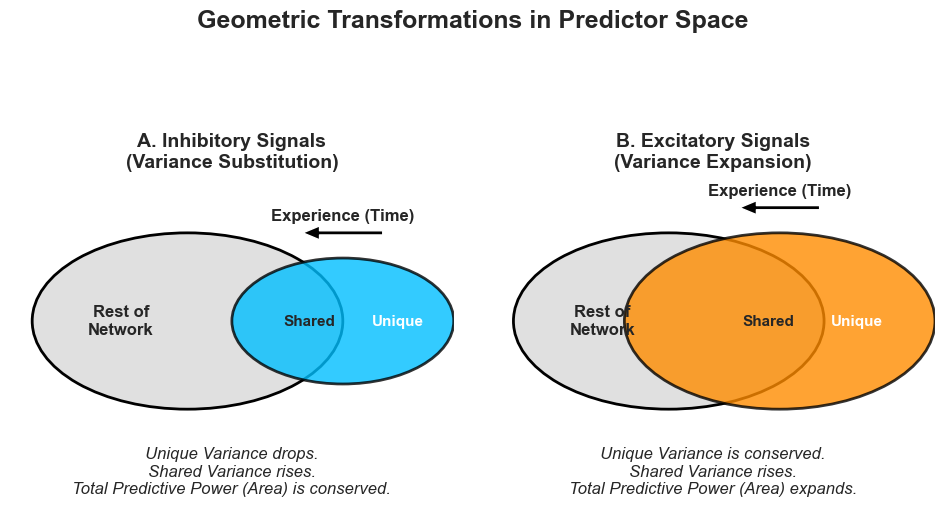

In [505]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import seaborn as sns

# --- Figure Setup ---
plt.rcParams['font.family'] = 'Arial'
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Geometric Transformations in Predictor Space', fontsize=18, fontweight='bold', y=1.05)

# Common styling
network_color = '#E0E0E0'
edge_color = 'black'
lw = 2

def draw_venn(ax, title, roi_color, roi_radius, roi_center_x, text_notes):
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')
    
    # Rest of Network (Constant across all plots)
    network = Circle((4, 5), 3.5, color=network_color, ec=edge_color, lw=lw, zorder=1)
    ax.add_patch(network)
    ax.text(2.5, 5, "Rest of\nNetwork", ha='center', va='center', fontsize=12, fontweight='bold')
    
    # ROI (Changes based on condition)
    roi = Circle((roi_center_x, 5), roi_radius, color=roi_color, ec=edge_color, lw=lw, alpha=0.8, zorder=2)
    ax.add_patch(roi)
    
    # Annotations
    ax.text(roi_center_x + (roi_radius*0.5), 5, "Unique", ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    ax.text((4 + roi_center_x)/2 + 1, 5, "Shared", ha='center', va='center', fontsize=11, fontweight='bold', zorder=3)
    
    # Explanatory Text below
    ax.text(5, 0, text_notes, ha='center', va='top', fontsize=12, style='italic', 
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.8))

# --- PANEL A: Inhibitory (Substitution / Rotation) ---
# The ROI size is constant (Radius=2.5), but it slides closer to the network center
draw_venn(axes[0], 'A. Inhibitory Signals\n(Variance Substitution)', 'deepskyblue', 
          roi_radius=2.5, roi_center_x=7.5, 
          text_notes="Unique Variance drops.\nShared Variance rises.\nTotal Predictive Power (Area) is conserved.")

# --- PANEL B: Excitatory (Expansion / Addition) ---
# The ROI unique crescent width is conserved, but the circle grows (Radius=3.5) and shifts left
draw_venn(axes[1], 'B. Excitatory Signals\n(Variance Expansion)', 'darkorange', 
          roi_radius=3.5, roi_center_x=6.5, 
          text_notes="Unique Variance is conserved.\nShared Variance rises.\nTotal Predictive Power (Area) expands.")

# Add visual arrows to represent the "push" over time
axes[0].annotate('', xy=(6.5, 8.5), xytext=(8.5, 8.5), 
                 arrowprops=dict(facecolor='black', shrink=0.05, width=3, headwidth=10))
axes[0].text(7.5, 9, "Experience (Time)", ha='center', fontsize=12, fontweight='bold')

axes[1].annotate('', xy=(5.5, 9.5), xytext=(7.5, 9.5), 
                 arrowprops=dict(facecolor='black', shrink=0.05, width=3, headwidth=10))
axes[1].text(6.5, 10, "Experience (Time)", ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

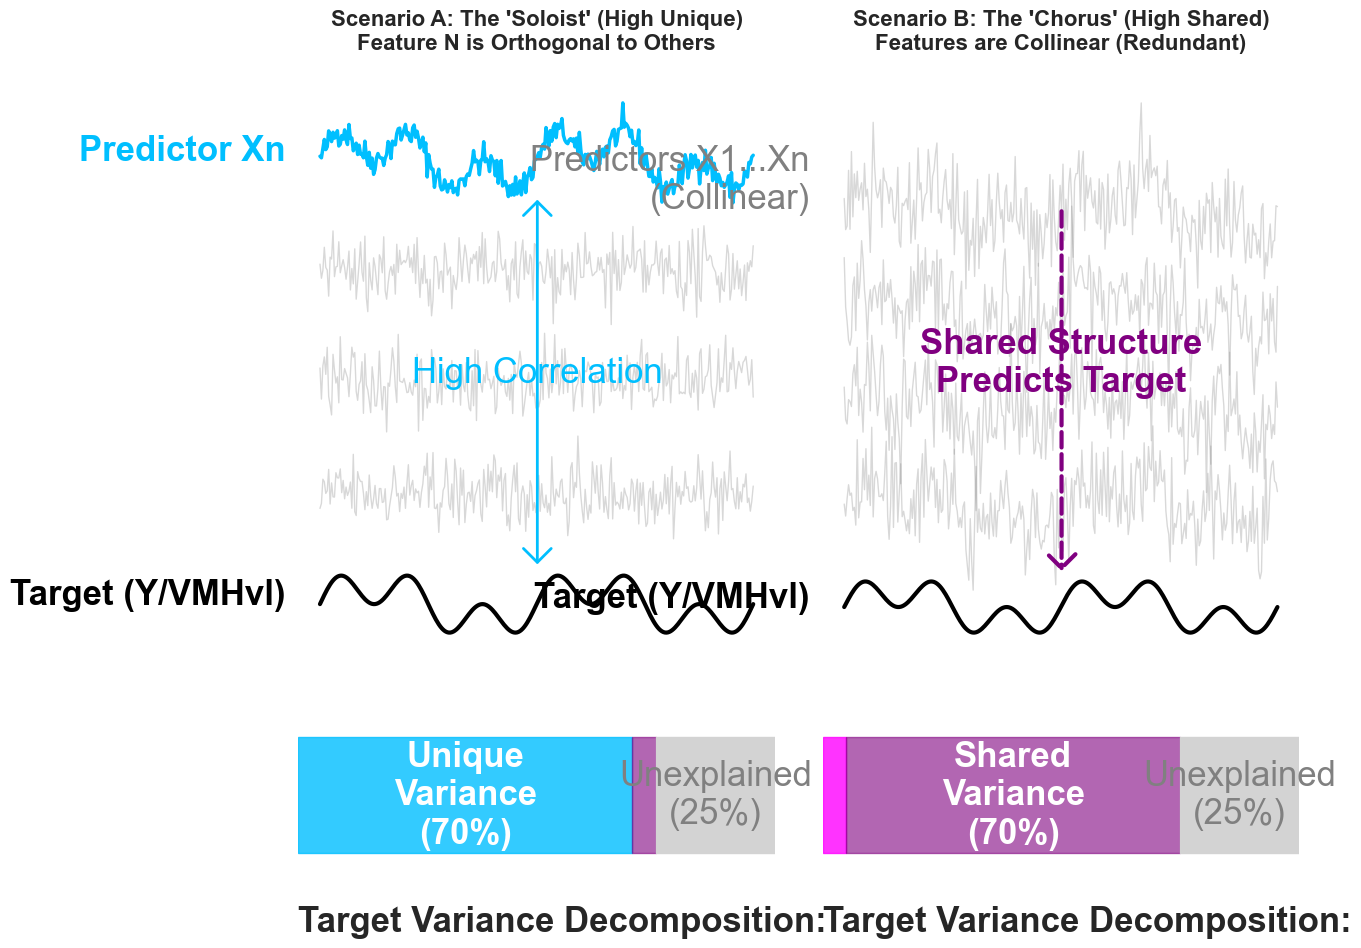

In [ ]:
from matplotlib.patches import Rectangle

# ==========================================
# SETUP & DATA GENERATION
# ==========================================
plt.rcParams['font.family'] = 'Arial'
np.random.seed(42) # for reproducible schematic noise

t = np.linspace(0, 8*np.pi, 300)

# --- Scenario A Data: High Unique Variance ---
# Target: A clear, structured signal
target_A = np.sin(t) * np.cos(t/2) 

# Predictor N (The Soloist): Highly correlated with Target
pred_N_A = target_A + np.random.normal(0, 0.2, len(t)) # Target + slight noise

# Other Predictors (Noise): Orthogonal to Target and Pred N
others_A = [np.random.normal(0, 0.5, len(t)) for _ in range(3)]


# --- Scenario B Data: High Shared Variance ---
# Target: Same clear structure
target_B = target_A 

# The Shared Component (hidden variable driving the collinearity)
shared_driver = target_B

# Predictors (The Chorus): None match perfectly on their own.
# They are all the shared driver + significant independent noise.
# They are collinear because they share the 'shared_driver'.
preds_B = [shared_driver + np.random.normal(0, 0.8, len(t)) for _ in range(4)]

# ==========================================
# PLOTTING FUNCTIONS
# ==========================================
def plot_signals(ax, target, main_pred, other_preds, title, highlight_color):
    # Plot "Other" predictors in background gray
    offset = 0
    for p in other_preds:
        ax.plot(t, p + offset, color='grey', alpha=0.3, lw=1)
        offset += 3
        
    # Plot Main Predictor (if it exists distinct from others)
    if main_pred is not None:
        ax.plot(t, main_pred + offset, color=highlight_color, lw=2.5, label='Key Predictor (Xn)')
        ax.text(t[0]-2, offset, 'Predictor Xn', color=highlight_color, fontweight='bold', ha='right')
        offset += 3
    else:
        # Scenario B case: label the top "other" predictor
        ax.text(t[0]-2, offset-3, 'Predictors X1...Xn\n(Collinear)', color='grey', ha='right')

    # Plot Target at the bottom
    target_offset = -3
    ax.plot(t, target + target_offset, 'k', lw=3, label='Target (Y)')
    ax.text(t[0]-2, target_offset, 'Target (Y/VMHvl)', color='k', fontweight='bold', ha='right')

    # Visual connections showing correlation
    if main_pred is not None:
        # Connect Xn to Target
        ax.annotate('', xy=(t[150], target_offset+1), xytext=(t[150], offset-3-1),
                    arrowprops=dict(arrowstyle='<->, head_width=0.4', color=highlight_color, lw=2))
        ax.text(t[150], (target_offset + offset-3)/2, 'High Correlation', 
                color=highlight_color, ha='center')
    else:
        # Connect all predictors down towards target generally
        ax.annotate('', xy=(t[150], target_offset+1), xytext=(t[150], offset-3),
                    arrowprops=dict(arrowstyle='->, head_width=0.4', color='purple', lw=3, ls='--'))
        ax.text(t[150], (target_offset + offset)/2 - 1, 'Shared Structure\nPredicts Target', 
                color='purple', ha='center', fontweight='bold')


    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    ax.axis('off')

def draw_variance_bar(ax, unique_pct, shared_pct, unexplained_pct, color_unique):
    # Helper to draw schematic variance composition bars
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 1)
    ax.axis('off')
    
    # Unique Part
    rect_u = Rectangle((0, 0.2), unique_pct, 0.6, color=color_unique, alpha=0.8)
    ax.add_patch(rect_u)
    if unique_pct > 10:
        ax.text(unique_pct/2, 0.5, f'Unique\nVariance\n({unique_pct}%)', 
                ha='center', va='center', color='white', fontweight='bold')
        
    # Shared Part
    rect_s = Rectangle((unique_pct, 0.2), shared_pct, 0.6, color='purple', alpha=0.6)
    ax.add_patch(rect_s)
    if shared_pct > 10:
        ax.text(unique_pct + shared_pct/2, 0.5, f'Shared\nVariance\n({shared_pct}%)', 
                ha='center', va='center', color='white', fontweight='bold')
        
    # Unexplained Part
    rect_n = Rectangle((unique_pct + shared_pct, 0.2), unexplained_pct, 0.6, color='lightgrey', hatch='///')
    ax.add_patch(rect_n)
    ax.text(unique_pct + shared_pct + unexplained_pct/2, 0.5, f'Unexplained\n({unexplained_pct}%)', 
            ha='center', va='center', color='grey')
    
    ax.text(0, -0.2, "Target Variance Decomposition:", fontweight='bold')


# ==========================================
# MAIN FIGURE GENERATION
# ==========================================
fig = plt.figure(figsize=(14, 10))

# Layout: Top row for signals, bottom row for variance bars
gs = fig.add_gridspec(2, 2, height_ratios=[3, 1])
ax_A_sig = fig.add_subplot(gs[0, 0])
ax_B_sig = fig.add_subplot(gs[0, 1])
ax_A_var = fig.add_subplot(gs[1, 0])
ax_B_var = fig.add_subplot(gs[1, 1])

# --- Plot Scenario A ---
plot_signals(ax_A_sig, target_A, pred_N_A, others_A, 
             title="Scenario A: The 'Soloist' (High Unique)\nFeature N is Orthogonal to Others",
             highlight_color='deepskyblue')

draw_variance_bar(ax_A_var, unique_pct=70, shared_pct=5, unexplained_pct=25, color_unique='deepskyblue')

# --- Plot Scenario B ---
# For B, we pass None for main_pred to treat them all as a group
plot_signals(ax_B_sig, target_B, None, preds_B, 
             title="Scenario B: The 'Chorus' (High Shared)\nFeatures are Collinear (Redundant)",
             highlight_color='magenta') # Highlight color unused here but kept for fun sig

draw_variance_bar(ax_B_var, unique_pct=5, shared_pct=70, unexplained_pct=25, color_unique='magenta')


plt.tight_layout()
plt.subplots_adjust(wspace=0.1, hspace=0.1)
# plt.savefig('./schematic_variance_explained.svg', format='svg')
plt.show()